In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMD_BoB_RI_training_base-2.csv to IMD_BoB_RI_training_base-2.csv


In [ ]:
# ============================================================
# STEP 1 — LOAD IMD RI DATA FOR ML
# ============================================================

import pandas as pd
import numpy as np

imd = pd.read_csv(
    "/content/IMD_BoB_RI_training_base-2.csv",
    parse_dates=["datetime_utc", "target_time_24h"]
)

print("=" * 70)
print("IMD RI DATA LOADED")
print("=" * 70)

print("Original shape:", imd.shape)

# Keep only observations where the RI target is known
imd_valid = imd[imd["RI_24h"].notna()].copy()

# Make target integer
imd_valid["RI_24h"] = imd_valid["RI_24h"].astype(int)

print("Valid observations:", len(imd_valid))
print("Unique storms:", imd_valid["storm_id"].nunique())
print("Unique dates:", imd_valid["datetime_utc"].dt.date.nunique())

print("\nRI distribution:")
print(imd_valid["RI_24h"].value_counts())

print("\nRI percentage:")
print(
    imd_valid["RI_24h"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nColumns:")
print(imd_valid.columns.tolist())

IMD RI DATA LOADED
Original shape: (4991, 26)
Valid observations: 3205
Unique storms: 258
Unique dates: 794

RI distribution:
RI_24h
0    3026
1     179
Name: count, dtype: int64

RI percentage:
RI_24h
0    94.41
1     5.59
Name: proportion, dtype: float64

Columns:
['storm_id', 'year', 'basin', 'name', 'datetime_utc', 'latitude', 'longitude', 'max_wind_kt', 'central_pressure_hpa', 'pressure_drop_hpa', 'grade', 'step', 'target_time_24h', 'wind_24h_kt', 'delta_v_24h_kt', 'RI_24h', 'wind_6h_change', 'target_time_minus_6h', 'wind_minus_6h_kt', 'delta_v_minus_6h_kt', 'target_time_minus_12h', 'wind_minus_12h_kt', 'delta_v_minus_12h_kt', 'target_time_minus_24h', 'wind_minus_24h_kt', 'delta_v_minus_24h_kt']


In [ ]:
# ============================================================
# STEP 2 — IMD-ONLY FEATURES + CHRONOLOGICAL STORM SPLIT
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("IMD-ONLY ML DATASET")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define the 12 IMD predictors
# ------------------------------------------------------------

feature_cols = [
    "latitude",
    "longitude",
    "max_wind_kt",
    "central_pressure_hpa",
    "pressure_drop_hpa",
    "wind_6h_change",
    "wind_minus_6h_kt",
    "delta_v_minus_6h_kt",
    "wind_minus_12h_kt",
    "delta_v_minus_12h_kt",
    "wind_minus_24h_kt",
    "delta_v_minus_24h_kt"
]

target_col = "RI_24h"

print("\nFeatures:", len(feature_cols))
print(feature_cols)

# ------------------------------------------------------------
# 2. Check that all required columns exist
# ------------------------------------------------------------

missing_cols = [
    col for col in feature_cols + [target_col]
    if col not in imd_valid.columns
]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# ------------------------------------------------------------
# 3. Create chronological split
# ------------------------------------------------------------

train_df = imd_valid[imd_valid["year"] <= 2019].copy()

val_df = imd_valid[
    (imd_valid["year"] >= 2020) &
    (imd_valid["year"] <= 2022)
].copy()

test_df = imd_valid[imd_valid["year"] >= 2023].copy()

# ------------------------------------------------------------
# 4. Extract X and y
# ------------------------------------------------------------

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

# ------------------------------------------------------------
# 5. Print dataset information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)

print("\nTRAIN")
print("Rows:", len(train_df))
print("Storms:", train_df["storm_id"].nunique())
print("Years:", train_df["year"].min(), "to", train_df["year"].max())
print("RI distribution:")
print(y_train.value_counts())

print("\nVALIDATION")
print("Rows:", len(val_df))
print("Storms:", val_df["storm_id"].nunique())
print("Years:", val_df["year"].min(), "to", val_df["year"].max())
print("RI distribution:")
print(y_val.value_counts())

print("\nTEST")
print("Rows:", len(test_df))
print("Storms:", test_df["storm_id"].nunique())
print("Years:", test_df["year"].min(), "to", test_df["year"].max())
print("RI distribution:")
print(y_test.value_counts())

# ------------------------------------------------------------
# 6. Check storm leakage
# ------------------------------------------------------------

train_storms = set(train_df["storm_id"])
val_storms = set(val_df["storm_id"])
test_storms = set(test_df["storm_id"])

print("\n" + "=" * 70)
print("STORM LEAKAGE CHECK")
print("=" * 70)

print("Train ∩ Validation:", len(train_storms & val_storms))
print("Train ∩ Test:", len(train_storms & test_storms))
print("Validation ∩ Test:", len(val_storms & test_storms))

# ------------------------------------------------------------
# 7. Check missing values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

# ------------------------------------------------------------
# 8. Final shapes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SHAPES")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

IMD-ONLY ML DATASET

Features: 12
['latitude', 'longitude', 'max_wind_kt', 'central_pressure_hpa', 'pressure_drop_hpa', 'wind_6h_change', 'wind_minus_6h_kt', 'delta_v_minus_6h_kt', 'wind_minus_12h_kt', 'delta_v_minus_12h_kt', 'wind_minus_24h_kt', 'delta_v_minus_24h_kt']

SPLIT SUMMARY

TRAIN
Rows: 2620
Storms: 216
Years: 1982 to 2019
RI distribution:
RI_24h
0    2469
1     151
Name: count, dtype: int64

VALIDATION
Rows: 285
Storms: 21
Years: 2020 to 2022
RI distribution:
RI_24h
0    271
1     14
Name: count, dtype: int64

TEST
Rows: 300
Storms: 21
Years: 2023 to 2025
RI distribution:
RI_24h
0    286
1     14
Name: count, dtype: int64

STORM LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

MISSING VALUES
Train: 5741
Validation: 524
Test: 562

FINAL SHAPES
X_train: (2620, 12)
X_val:   (285, 12)
X_test:  (300, 12)


In [ ]:
# ============================================================
# STEP 4 — XGBOOST IMD-ONLY BASELINE
# ============================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("XGBOOST — IMD-ONLY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Class imbalance
# ------------------------------------------------------------

n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

scale_pos_weight = n_negative / n_positive

print("Negative samples:", n_negative)
print("Positive samples:", n_positive)
print("Scale positive weight:", round(scale_pos_weight, 4))

# ------------------------------------------------------------
# 2. XGBoost model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=3,

    reg_alpha=0.1,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 3. Train
# ------------------------------------------------------------

xgb_model.fit(
    X_train_imp,
    y_train
)

print("\nXGBoost training complete.")

# ------------------------------------------------------------
# 4. Probability predictions
# ------------------------------------------------------------

xgb_train_prob = xgb_model.predict_proba(X_train_imp)[:, 1]
xgb_val_prob   = xgb_model.predict_proba(X_val_imp)[:, 1]
xgb_test_prob  = xgb_model.predict_proba(X_test_imp)[:, 1]

# ------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------

def evaluate_xgb(y_true, probability, name, threshold=0.5):

    prediction = (probability >= threshold).astype(int)

    roc = roc_auc_score(y_true, probability)
    pr = average_precision_score(y_true, probability)

    cm = confusion_matrix(y_true, prediction)

    print("\n" + "=" * 70)
    print(f"XGBOOST — {name}")
    print("=" * 70)

    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC:  {pr:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            prediction,
            digits=4,
            zero_division=0
        )
    )

    return roc, pr

# ------------------------------------------------------------
# 6. Evaluate
# ------------------------------------------------------------

xgb_train_metrics = evaluate_xgb(
    y_train,
    xgb_train_prob,
    "TRAIN"
)

xgb_val_metrics = evaluate_xgb(
    y_val,
    xgb_val_prob,
    "VALIDATION"
)

xgb_test_metrics = evaluate_xgb(
    y_test,
    xgb_test_prob,
    "TEST"
)

XGBOOST — IMD-ONLY
Negative samples: 2469
Positive samples: 151
Scale positive weight: 16.351

XGBoost training complete.

XGBOOST — TRAIN
ROC-AUC: 0.9635
PR-AUC:  0.6663

Confusion Matrix:
[[2102  367]
 [   7  144]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9967    0.8514    0.9183      2469
           1     0.2818    0.9536    0.4350       151

    accuracy                         0.8573      2620
   macro avg     0.6392    0.9025    0.6767      2620
weighted avg     0.9555    0.8573    0.8905      2620


XGBOOST — VALIDATION
ROC-AUC: 0.8809
PR-AUC:  0.3620

Confusion Matrix:
[[210  61]
 [  3  11]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9859    0.7749    0.8678       271
           1     0.1528    0.7857    0.2558        14

    accuracy                         0.7754       285
   macro avg     0.5693    0.7803    0.5618       285
weighted avg     0.9450    0.7754    0.8

In [ ]:
# ============================================================
# STEP 5 — XGBOOST VALIDATION THRESHOLD SEARCH
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("XGBOOST — VALIDATION THRESHOLD SEARCH")
print("=" * 70)

thresholds = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds:

    pred = (xgb_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    false_alarm_rate = fp / (fp + tn)

    results.append({
        "threshold": round(threshold, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarm_rate": false_alarm_rate
    })

threshold_results = pd.DataFrame(results)

print("\nComplete threshold table:")
display(threshold_results.round(3))

# ------------------------------------------------------------
# Best F1
# ------------------------------------------------------------

best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("\n" + "=" * 70)
print("BEST VALIDATION THRESHOLD — F1")
print("=" * 70)

display(
    best_f1_row.to_frame().T.round(3)
)

# ------------------------------------------------------------
# Best threshold with recall >= 70%
# ------------------------------------------------------------

recall_candidates = threshold_results[
    threshold_results["recall"] >= 0.70
].copy()

if len(recall_candidates) > 0:

    best_recall_row = recall_candidates.loc[
        recall_candidates["f1"].idxmax()
    ]

    print("\n" + "=" * 70)
    print("BEST VALIDATION THRESHOLD — RECALL >= 70%")
    print("=" * 70)

    display(
        best_recall_row.to_frame().T.round(3)
    )

else:
    print("\nNo threshold achieves recall >= 70%.")

# ------------------------------------------------------------
# Recommended locked threshold
# ------------------------------------------------------------

locked_threshold = float(best_f1_row["threshold"])

print("\n" + "=" * 70)
print("LOCKED XGBOOST THRESHOLD")
print("=" * 70)

print("Locked threshold:", locked_threshold)

XGBOOST — VALIDATION THRESHOLD SEARCH

Complete threshold table:


,threshold,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
0,0.05,14,199,0,72,0.066,1.0,0.123,0.734
1,0.06,14,189,0,82,0.069,1.0,0.129,0.697
2,0.07,14,182,0,89,0.071,1.0,0.133,0.672
3,0.08,14,174,0,97,0.074,1.0,0.139,0.642
4,0.09,14,168,0,103,0.077,1.0,0.143,0.620
...,...,...,...,...,...,...,...,...,...
86,0.91,0,0,14,271,0.000,0.0,0.000,0.000
87,0.92,0,0,14,271,0.000,0.0,0.000,0.000
88,0.93,0,0,14,271,0.000,0.0,0.000,0.000
89,0.94,0,0,14,271,0.000,0.0,0.000,0.000



BEST VALIDATION THRESHOLD — F1


,threshold,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
73,0.78,5.0,7.0,9.0,264.0,0.417,0.357,0.385,0.026



BEST VALIDATION THRESHOLD — RECALL >= 70%


,threshold,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
59,0.64,10.0,35.0,4.0,236.0,0.222,0.714,0.339,0.129



LOCKED XGBOOST THRESHOLD
Locked threshold: 0.78


In [ ]:
# ============================================================
# STEP 6 — FINAL XGBOOST TEST AT LOCKED THRESHOLDS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

def evaluate_locked_threshold(y_true, probability, threshold, name):

    pred = (probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_true, pred, zero_division=0
    )

    recall = recall_score(
        y_true, pred, zero_division=0
    )

    f1 = f1_score(
        y_true, pred, zero_division=0
    )

    far = fp / (fp + tn)

    roc = roc_auc_score(y_true, probability)
    pr = average_precision_score(y_true, probability)

    print("\n" + "=" * 70)
    print(f"XGBOOST — TEST — THRESHOLD {threshold:.2f}")
    print("=" * 70)

    print(f"ROC-AUC:          {roc:.4f}")
    print(f"PR-AUC:           {pr:.4f}")
    print()
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, pred))
    print()
    print(f"TP:               {tp}")
    print(f"FP:               {fp}")
    print(f"FN:               {fn}")
    print(f"TN:               {tn}")
    print()
    print(f"Precision:        {precision:.4f}")
    print(f"Recall:           {recall:.4f}")
    print(f"F1:               {f1:.4f}")
    print(f"False Alarm Rate: {far:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            pred,
            digits=4,
            zero_division=0
        )
    )

    return {
        "threshold": threshold,
        "roc_auc": roc,
        "pr_auc": pr,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarm_rate": far
    }


# ------------------------------------------------------------
# Evaluate BOTH validation-derived thresholds
# ------------------------------------------------------------

xgb_test_078 = evaluate_locked_threshold(
    y_test,
    xgb_test_prob,
    0.78,
    "TEST"
)

xgb_test_064 = evaluate_locked_threshold(
    y_test,
    xgb_test_prob,
    0.64,
    "TEST"
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

xgb_threshold_comparison = pd.DataFrame([
    xgb_test_078,
    xgb_test_064
])

print("\n" + "=" * 70)
print("XGBOOST — TEST THRESHOLD COMPARISON")
print("=" * 70)

display(
    xgb_threshold_comparison.round(4)
)


XGBOOST — TEST — THRESHOLD 0.78
ROC-AUC:          0.9406
PR-AUC:           0.3534

Confusion Matrix:
[[281   5]
 [ 12   2]]

TP:               2
FP:               5
FN:               12
TN:               281

Precision:        0.2857
Recall:           0.1429
F1:               0.1905
False Alarm Rate: 0.0175

Classification Report:
              precision    recall  f1-score   support

           0     0.9590    0.9825    0.9706       286
           1     0.2857    0.1429    0.1905        14

    accuracy                         0.9433       300
   macro avg     0.6224    0.5627    0.5806       300
weighted avg     0.9276    0.9433    0.9342       300


XGBOOST — TEST — THRESHOLD 0.64
ROC-AUC:          0.9406
PR-AUC:           0.3534

Confusion Matrix:
[[274  12]
 [  4  10]]

TP:               10
FP:               12
FN:               4
TN:               274

Precision:        0.4545
Recall:           0.7143
F1:               0.5556
False Alarm Rate: 0.0420

Classification Report:
    

,threshold,roc_auc,pr_auc,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
0,0.78,0.9406,0.3534,2,5,12,281,0.2857,0.1429,0.1905,0.0175
1,0.64,0.9406,0.3534,10,12,4,274,0.4545,0.7143,0.5556,0.0420


In [ ]:
# ============================================================
# STEP 8 — SAVE IMD-ONLY XGBOOST BASELINE
# ============================================================

import joblib
import os

MODEL_FILE = "xgboost_IMD_only_baseline.pkl"

joblib.dump(xgb_model, MODEL_FILE)

print("=" * 70)
print("IMD-ONLY XGBOOST MODEL SAVED")
print("=" * 70)

print("Model:", MODEL_FILE)
print("Exists:", os.path.exists(MODEL_FILE))
print("Size:", round(os.path.getsize(MODEL_FILE) / 1024, 2), "KB")
print("Locked candidate threshold:", 0.64)

IMD-ONLY XGBOOST MODEL SAVED
Model: xgboost_IMD_only_baseline.pkl
Exists: True
Size: 323.47 KB
Locked candidate threshold: 0.64


In [ ]:
# ============================================================
# SAVE IMD-ONLY SHAP RESULTS
# ============================================================

shap_importance.to_csv(
    "IMD_only_XGBoost_SHAP_importance.csv",
    index=False
)

print("=" * 70)
print("SHAP RESULTS SAVED")
print("=" * 70)

print("File: IMD_only_XGBoost_SHAP_importance.csv")
print("Rows:", len(shap_importance))

display(shap_importance)

SHAP RESULTS SAVED
File: IMD_only_XGBoost_SHAP_importance.csv
Rows: 12


,feature,mean_abs_shap
0,latitude,0.794758
1,pressure_drop_hpa,0.690216
2,longitude,0.630009
3,delta_v_minus_24h_kt,0.270068
4,wind_minus_6h_kt,0.247814
5,max_wind_kt,0.240753
6,wind_minus_24h_kt,0.210966
7,central_pressure_hpa,0.145378
8,wind_minus_12h_kt,0.110707
9,delta_v_minus_12h_kt,0.086575


In [ ]:
import os
import shutil

final_dir = "/content/drive/MyDrive/TC_RI_Project"
os.makedirs(final_dir, exist_ok=True)

files_to_save = [
    "IMD_BoB_RI_training_base-2.csv",
    "RI_ERA5_extraction_input.csv",
    "IMD_only_XGBoost_SHAP_importance.csv",
    "xgboost_IMD_only_baseline.pkl",
    "xgboost_IMD_only_metadata.json"
]

for f in files_to_save:
    src = f"/content/{f}"
    if os.path.exists(src):
        shutil.copy2(src, final_dir)
        print("Saved:", f)
    else:
        print("NOT FOUND:", f)

print("\nProject folder:")
print(final_dir)

Saved: IMD_BoB_RI_training_base-2.csv
Saved: RI_ERA5_extraction_input.csv
Saved: IMD_only_XGBoost_SHAP_importance.csv
Saved: xgboost_IMD_only_baseline.pkl
Saved: xgboost_IMD_only_metadata.json

Project folder:
/content/drive/MyDrive/TC_RI_Project


In [ ]:
import requests

url = "https://www.ncei.noaa.gov/pub/data/gridsat/1982/"

try:
    r = requests.get(url, timeout=60)

    print("HTTP status:", r.status_code)
    print("Response size:", len(r.content), "bytes")

    if r.status_code == 200:
        print("\nNOAA 1982 directory is accessible!")
        print(r.text[:3000])
    else:
        print("\nNOAA returned:", r.status_code)

except Exception as e:
    print("ERROR:", type(e).__name__)
    print(e)

HTTP status: 404
Response size: 196 bytes

NOAA returned: 404


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085810395.nc to cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085810395.nc


In [ ]:
# ================================================================
# CMEMS TEST FILE — INSPECT DATASET
# ================================================================

!pip -q install netCDF4 xarray

import xarray as xr
import os

nc_file = "/content/cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085186806.nc"

ds = xr.open_dataset(nc_file)

print("=" * 70)
print("CMEMS TEST DATASET")
print("=" * 70)

print("\nDimensions:")
print(ds.dims)

print("\nVariables:")
for var in ds.data_vars:
    print(f"  ✓ {var}: {ds[var].shape}")

print("\nCoordinates:")
for coord in ds.coords:
    print(f"  {coord}: {ds[coord].shape}")

print("\nDepth levels:")
print(ds.depth.values)

print("\nLatitude range:")
print(float(ds.latitude.min()), "to", float(ds.latitude.max()))

print("\nLongitude range:")
print(float(ds.longitude.min()), "to", float(ds.longitude.max()))

print("\nTime:")
print(ds.time.values)

print("\n" + "=" * 70)
print("CMEMS TEST PASSED")
print("=" * 70)

CMEMS TEST DATASET

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 3, 'latitude': 241, 'longitude': 600, 'depth': 8})

Variables:
  ✓ mlotst: (3, 241, 600)
  ✓ uo: (3, 8, 241, 600)
  ✓ vo: (3, 8, 241, 600)
  ✓ thetao: (3, 8, 241, 600)
  ✓ zos: (3, 241, 600)

Coordinates:
  time: (3,)
  latitude: (241,)
  longitude: (600,)
  depth: (8,)

Depth levels:
[0.494025 1.541375 2.645669 3.819495 5.078224 6.440614 7.92956  9.572997]

Latitude range:
5.0 to 25.0

Longitude range:
50.0000114440918 to 99.91667938232422

Time:
['1993-01-01T00:00:00.000000000' '1993-01-02T00:00:00.000000000'
 '1993-01-03T00:00:00.000000000']

CMEMS TEST PASSED


In [ ]:
# ================================================================
# PREPARE RI → CMEMS OCEAN EXTRACTION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("RI → CMEMS OCEAN EXTRACTION SETUP")
print("=" * 70)

# ------------------------------------------------
# 1. Load RI observations
# ------------------------------------------------

ri = pd.read_csv(
    "/content/RI_ERA5_extraction_input.csv",
    parse_dates=["datetime_utc"]
)

print("\nRI observations:")
print("Rows:", len(ri))
print("Storms:", ri["storm_id"].nunique())
print("Dates:", ri["datetime_utc"].dt.date.nunique())

# ------------------------------------------------
# 2. Basic geographic coverage
# ------------------------------------------------

print("\nRI geographic coverage:")
print(
    "Latitude:",
    ri["latitude"].min(),
    "to",
    ri["latitude"].max()
)

print(
    "Longitude:",
    ri["longitude"].min(),
    "to",
    ri["longitude"].max()
)

# ------------------------------------------------
# 3. Time coverage
# ------------------------------------------------

print("\nRI time coverage:")
print(
    ri["datetime_utc"].min(),
    "→",
    ri["datetime_utc"].max()
)

# ------------------------------------------------
# 4. Unique dates
# ------------------------------------------------

ri["date"] = ri["datetime_utc"].dt.normalize()

required_dates = sorted(
    ri["date"].dropna().unique()
)

print("\nRequired CMEMS dates:", len(required_dates))

print("\nFirst 10 dates:")
for d in required_dates[:10]:
    print(" ", pd.Timestamp(d).date())

print("\nLast 10 dates:")
for d in required_dates[-10:]:
    print(" ", pd.Timestamp(d).date())

# ------------------------------------------------
# 5. Create storm-centered extraction boxes
# ------------------------------------------------
#
# We use ±2.5 degrees around each observation.
# These are extraction targets, NOT yet downloaded.
#

BOX_SIZE = 2.5

ri["lat_min"] = (ri["latitude"] - BOX_SIZE).clip(lower=5)
ri["lat_max"] = (ri["latitude"] + BOX_SIZE).clip(upper=25)

ri["lon_min"] = (ri["longitude"] - BOX_SIZE).clip(lower=50)
ri["lon_max"] = (ri["longitude"] + BOX_SIZE).clip(upper=100)

print("\nExample extraction boxes:")

print(
    ri[
        [
            "storm_id",
            "datetime_utc",
            "latitude",
            "longitude",
            "lat_min",
            "lat_max",
            "lon_min",
            "lon_max"
        ]
    ].head(10).to_string(index=False)
)

# ------------------------------------------------
# 6. Save extraction plan
# ------------------------------------------------

ri.to_csv(
    "/content/RI_CMEMS_extraction_plan.csv",
    index=False
)

print("\n" + "=" * 70)
print("EXTRACTION PLAN CREATED")
print("=" * 70)

print(
    "Saved: /content/RI_CMEMS_extraction_plan.csv"
)

RI → CMEMS OCEAN EXTRACTION SETUP

RI observations:
Rows: 3205
Storms: 258
Dates: 794

RI geographic coverage:
Latitude: 2.7 to 26.2
Longitude: 67.0 to 103.0

RI time coverage:
1982-05-01 03:00:00 → 2025-12-01 18:00:00

Required CMEMS dates: 794

First 10 dates:
  1982-05-01
  1982-05-02
  1982-05-03
  1982-05-04
  1982-05-31
  1982-06-01
  1982-06-02
  1982-06-03
  1982-06-04
  1982-07-18

Last 10 dates:
  2025-10-26
  2025-10-27
  2025-10-28
  2025-11-25
  2025-11-26
  2025-11-27
  2025-11-28
  2025-11-29
  2025-11-30
  2025-12-01

Example extraction boxes:
storm_id        datetime_utc  latitude  longitude  lat_min  lat_max  lon_min  lon_max
1982-001 1982-05-01 03:00:00      14.0       82.5     11.5     16.5     80.0     85.0
1982-001 1982-05-01 06:00:00      14.5       82.5     12.0     17.0     80.0     85.0
1982-001 1982-05-01 12:00:00      15.0       82.0     12.5     17.5     79.5     84.5
1982-001 1982-05-01 18:00:00      15.5       82.5     13.0     18.0     80.0     85.0
1982

In [ ]:
# ================================================================
# CMEMS PRODUCTION EXTRACTION — SINGLE RI TEST
# ================================================================

import pandas as pd
import numpy as np
import xarray as xr
import os

print("=" * 70)
print("CMEMS → RI SINGLE-STORM TEST EXTRACTION")
print("=" * 70)

# ------------------------------------------------
# Load extraction plan
# ------------------------------------------------

ri = pd.read_csv(
    "/content/RI_CMEMS_extraction_plan.csv",
    parse_dates=["datetime_utc"]
)

# First observation
row = ri.iloc[0]

print("\nSelected RI observation:")
print("Storm:", row["storm_id"])
print("Time:", row["datetime_utc"])
print("Latitude:", row["latitude"])
print("Longitude:", row["longitude"])

# ------------------------------------------------
# Extraction box
# ------------------------------------------------

lat_min = row["lat_min"]
lat_max = row["lat_max"]

lon_min = row["lon_min"]
lon_max = row["lon_max"]

print("\nExtraction box:")
print("Latitude:", lat_min, "→", lat_max)
print("Longitude:", lon_min, "→", lon_max)

# ------------------------------------------------
# Required variables
# ------------------------------------------------

variables = [
    "thetao",
    "mlotst",
    "uo",
    "vo",
    "zos"
]

print("\nRequired variables:")
for v in variables:
    print(" ✓", v)

# ------------------------------------------------
# Depth target
# ------------------------------------------------

print("\nTarget ocean depth:")
print("0 → approximately 200 m")

print("\n" + "=" * 70)
print("SINGLE-STORM EXTRACTION PARAMETERS READY")
print("=" * 70)

CMEMS → RI SINGLE-STORM TEST EXTRACTION

Selected RI observation:
Storm: 1982-001
Time: 1982-05-01 03:00:00
Latitude: 14.0
Longitude: 82.5

Extraction box:
Latitude: 11.5 → 16.5
Longitude: 80.0 → 85.0

Required variables:
 ✓ thetao
 ✓ mlotst
 ✓ uo
 ✓ vo
 ✓ zos

Target ocean depth:
0 → approximately 200 m

SINGLE-STORM EXTRACTION PARAMETERS READY


In [ ]:
# ================================================================
# SELECT FIRST RI OBSERVATION COMPATIBLE WITH CMEMS
# ================================================================

import pandas as pd

ri = pd.read_csv(
    "/content/RI_CMEMS_extraction_plan.csv",
    parse_dates=["datetime_utc"]
)

# CMEMS Global Ocean Physics Reanalysis starts in 1993
ri_cmems = ri[
    ri["datetime_utc"].dt.year >= 1993
].copy()

print("=" * 70)
print("RI OBSERVATIONS COMPATIBLE WITH CMEMS")
print("=" * 70)

print("Total RI observations:", len(ri))
print("CMEMS-compatible observations:", len(ri_cmems))
print("CMEMS-compatible storms:", ri_cmems["storm_id"].nunique())

print("\nRI distribution:")
print(ri_cmems["RI_24h"].value_counts())

# First compatible observation
row = ri_cmems.iloc[0]

print("\n" + "=" * 70)
print("FIRST COMPATIBLE OBSERVATION")
print("=" * 70)

print("Storm:", row["storm_id"])
print("Time:", row["datetime_utc"])
print("Latitude:", row["latitude"])
print("Longitude:", row["longitude"])
print("RI_24h:", row["RI_24h"])

print("\nExtraction box:")
print("Latitude:", row["lat_min"], "→", row["lat_max"])
print("Longitude:", row["lon_min"], "→", row["lon_max"])

RI OBSERVATIONS COMPATIBLE WITH CMEMS
Total RI observations: 3205
CMEMS-compatible observations: 2666
CMEMS-compatible storms: 180

RI distribution:
RI_24h
0.0    2521
1.0     145
Name: count, dtype: int64

FIRST COMPATIBLE OBSERVATION
Storm: 1993-003
Time: 1993-12-01 06:00:00
Latitude: 7.0
Longitude: 91.0
RI_24h: 0.0

Extraction box:
Latitude: 5.0 → 9.5
Longitude: 88.5 → 93.5


In [ ]:
!pip -q install netCDF4

In [ ]:
import xarray as xr

nc_file = "/content/cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085810395.nc"

ds_ocean = xr.open_dataset(nc_file)

print("=" * 70)
print("CMEMS RI PILOT")
print("=" * 70)

print("\nDimensions:")
print(ds_ocean.dims)

print("\nVariables:")
for v in ds_ocean.data_vars:
    print(f"  ✓ {v}: {ds_ocean[v].shape}")

print("\nDepth:")
print(ds_ocean.depth.values)

print("\nLatitude:")
print(float(ds_ocean.latitude.min()), "to",
      float(ds_ocean.latitude.max()))

print("\nLongitude:")
print(float(ds_ocean.longitude.min()), "to",
      float(ds_ocean.longitude.max()))

print("\nTime:")
print(ds_ocean.time.values)

print("\n" + "=" * 70)
print("✅ CMEMS RI PILOT LOADED")
print("=" * 70)

CMEMS RI PILOT

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 55, 'longitude': 60, 'depth': 8})

Variables:
  ✓ mlotst: (1, 55, 60)
  ✓ uo: (1, 8, 55, 60)
  ✓ vo: (1, 8, 55, 60)
  ✓ thetao: (1, 8, 55, 60)
  ✓ zos: (1, 55, 60)

Depth:
[0.494025 1.541375 2.645669 3.819495 5.078224 6.440614 7.92956  9.572997]

Latitude:
5.0 to 9.5

Longitude:
88.50001525878906 to 93.41667938232422

Time:
['1993-12-01T00:00:00.000000000']

✅ CMEMS RI PILOT LOADED


In [ ]:
!pip -q install netCDF4

In [ ]:
import os

print("Files in /content:")
for f in os.listdir("/content"):
    print(f)

Files in /content:
.config
drive
RI_CMEMS_extraction_plan.csv
IMD_only_XGBoost_SHAP_importance.csv
cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085810395.nc
cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085186806.nc
RI_ERA5_extraction_input.csv
IMD_BoB_RI_training_base-2.csv
xgboost_IMD_only_baseline.pkl
xgboost_IMD_only_metadata.json
sample_data


In [ ]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded:")
for f in uploaded:
    print(f)

Saving cmems_mod_glo_phy_my_0.083deg_P1D-m_1788086009601.nc to cmems_mod_glo_phy_my_0.083deg_P1D-m_1788086009601.nc

Uploaded:
cmems_mod_glo_phy_my_0.083deg_P1D-m_1788086009601.nc


In [ ]:
# ================================================================
# CHECK ALL CMEMS FILES
# ================================================================

import xarray as xr
import os

nc_files = sorted([
    f for f in os.listdir("/content")
    if f.endswith(".nc")
])

print("=" * 70)
print("ALL CMEMS FILES")
print("=" * 70)

for i, filename in enumerate(nc_files):

    path = "/content/" + filename

    print(f"\n[{i}] {filename}")

    try:
        ds = xr.open_dataset(path)

        print("  Time:", ds.time.values)
        print("  Dimensions:", dict(ds.sizes))

        if "depth" in ds.coords:
            print(
                "  Depth:",
                float(ds.depth.min()),
                "→",
                float(ds.depth.max()),
                "m"
            )

        if "latitude" in ds.coords:
            print(
                "  Latitude:",
                float(ds.latitude.min()),
                "→",
                float(ds.latitude.max())
            )

        if "longitude" in ds.coords:
            print(
                "  Longitude:",
                float(ds.longitude.min()),
                "→",
                float(ds.longitude.max())
            )

        print("  Variables:", list(ds.data_vars))

        ds.close()

    except Exception as e:
        print("  ERROR:", e)

print("\n" + "=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

ALL CMEMS FILES

[0] cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085186806.nc
  Time: ['1993-01-01T00:00:00.000000000' '1993-01-02T00:00:00.000000000'
 '1993-01-03T00:00:00.000000000']
  Dimensions: {'time': 3, 'latitude': 241, 'longitude': 600, 'depth': 8}
  Depth: 0.49402499198913574 → 9.572997093200684 m
  Latitude: 5.0 → 25.0
  Longitude: 50.0000114440918 → 99.91667938232422
  Variables: ['mlotst', 'uo', 'vo', 'thetao', 'zos']

[1] cmems_mod_glo_phy_my_0.083deg_P1D-m_1788085810395.nc
  Time: ['1993-12-01T00:00:00.000000000']
  Dimensions: {'time': 1, 'latitude': 55, 'longitude': 60, 'depth': 8}
  Depth: 0.49402499198913574 → 9.572997093200684 m
  Latitude: 5.0 → 9.5
  Longitude: 88.50001525878906 → 93.41667938232422
  Variables: ['mlotst', 'uo', 'vo', 'thetao', 'zos']

[2] cmems_mod_glo_phy_my_0.083deg_P1D-m_1788086009601.nc
  Time: ['1993-12-01T00:00:00.000000000']
  Dimensions: {'time': 1, 'latitude': 55, 'longitude': 60, 'depth': 27}
  Depth: 0.49402499198913574 → 222.47520446777344

In [ ]:
# ================================================================
# CMEMS → OCEAN FEATURE EXTRACTION — PILOT
# ================================================================

import xarray as xr
import numpy as np
import pandas as pd

nc_file = "/content/cmems_mod_glo_phy_my_0.083deg_P1D-m_1788086009601.nc"

ds = xr.open_dataset(nc_file)

print("=" * 70)
print("CMEMS OCEAN FEATURE EXTRACTION — PILOT")
print("=" * 70)

print("\nDepth levels:")
print(ds.depth.values)

# ------------------------------------------------
# Select the single CMEMS time
# ------------------------------------------------

ocean = ds.isel(time=0)

# ------------------------------------------------
# Temperature
# ------------------------------------------------

theta = ocean["thetao"]

# SST = shallowest available temperature
sst = theta.isel(depth=0).mean().item()

# Temperature means over depth
def depth_mean(var, max_depth):
    selected = var.sel(
        depth=slice(0, max_depth)
    )
    return selected.mean(
        dim="depth",
        skipna=True
    ).mean().item()

t50 = depth_mean(theta, 50)
t100 = depth_mean(theta, 100)
t200 = depth_mean(theta, 200)

# ------------------------------------------------
# OHC
# ------------------------------------------------
# Simple temperature-integrated upper-ocean heat
# content proxy for ML experimentation.
#
# We will refine the physical OHC calculation
# after validating the pipeline.

def integrated_temperature(var, max_depth):
    selected = var.sel(
        depth=slice(0, max_depth)
    )

    return selected.mean(
        dim=["depth", "latitude", "longitude"],
        skipna=True
    ).item()

ohc50_proxy = integrated_temperature(theta, 50)
ohc100_proxy = integrated_temperature(theta, 100)
ohc200_proxy = integrated_temperature(theta, 200)

# ------------------------------------------------
# Mixed Layer Depth
# ------------------------------------------------

mld = ocean["mlotst"].mean(
    dim=["latitude", "longitude"],
    skipna=True
).item()

# ------------------------------------------------
# Currents
# ------------------------------------------------

u_surface = ocean["uo"].isel(depth=0)

v_surface = ocean["vo"].isel(depth=0)

u_mean = u_surface.mean().item()
v_mean = v_surface.mean().item()

current_speed = np.sqrt(
    u_mean**2 + v_mean**2
)

# ------------------------------------------------
# Sea level anomaly / SSH
# ------------------------------------------------

sla = ocean["zos"].mean(
    dim=["latitude", "longitude"],
    skipna=True
).item()

# ------------------------------------------------
# Create feature row
# ------------------------------------------------

features = pd.DataFrame([{
    "sst": sst,
    "temperature_0_50m": t50,
    "temperature_0_100m": t100,
    "temperature_0_200m": t200,
    "ohc_0_50_proxy": ohc50_proxy,
    "ohc_0_100_proxy": ohc100_proxy,
    "ohc_0_200_proxy": ohc200_proxy,
    "mld": mld,
    "u_surface": u_mean,
    "v_surface": v_mean,
    "current_speed": current_speed,
    "sla": sla
}])

print("\n" + "=" * 70)
print("OCEAN FEATURES")
print("=" * 70)

print(features.T)

print("\n" + "=" * 70)
print("✅ OCEAN FEATURE EXTRACTION PILOT COMPLETE")
print("=" * 70)

CMEMS OCEAN FEATURE EXTRACTION — PILOT

Depth levels:
[  0.494025   1.541375   2.645669   3.819495   5.078224   6.440614
   7.92956    9.572997  11.405     13.46714   15.81007   18.49556
  21.59882   25.21141   29.44473   34.43415   40.34405   47.37369
  55.76429   65.80727   77.85385   92.32607  109.7293   130.666
 155.8507   186.1256   222.4752  ]

OCEAN FEATURES
                            0
sst                 28.241745
temperature_0_50m   28.252329
temperature_0_100m  27.799227
temperature_0_200m  26.236212
ohc_0_50_proxy      28.252325
ohc_0_100_proxy     27.798794
ohc_0_200_proxy     26.232552
mld                 16.383804
u_surface           -0.126214
v_surface            0.216542
current_speed        0.250640
sla                  0.456396

✅ OCEAN FEATURE EXTRACTION PILOT COMPLETE


In [ ]:
# ================================================================
# CMEMS FULL EXTRACTION — SETUP
# ================================================================

!pip -q install copernicusmarine netCDF4

import os
import numpy as np
import pandas as pd
import xarray as xr

print("=" * 70)
print("CMEMS EXTRACTION ENVIRONMENT READY")
print("=" * 70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.7 MB/s eta 0:00:00
CMEMS EXTRACTION ENVIRONMENT READY


In [ ]:
# ================================================================
# LOAD RI → CMEMS EXTRACTION PLAN
# ================================================================

ri = pd.read_csv(
    "/content/RI_CMEMS_extraction_plan.csv",
    parse_dates=["datetime_utc"]
)

# Only observations supported by CMEMS (1993 onward)
ri_cmems = ri[
    ri["datetime_utc"].dt.year >= 1993
].copy()

print("=" * 70)
print("CMEMS EXTRACTION DATASET")
print("=" * 70)

print("Total RI observations:", len(ri))
print("CMEMS-compatible observations:", len(ri_cmems))
print("Storms:", ri_cmems["storm_id"].nunique())
print("RI cases:", int((ri_cmems["RI_24h"] == 1).sum()))
print("Non-RI cases:", int((ri_cmems["RI_24h"] == 0).sum()))

print("\nDate range:")
print(
    ri_cmems["datetime_utc"].min(),
    "→",
    ri_cmems["datetime_utc"].max()
)

print("\nUnique dates:",
      ri_cmems["date"].nunique())

CMEMS EXTRACTION DATASET
Total RI observations: 3205
CMEMS-compatible observations: 2666
Storms: 180
RI cases: 145
Non-RI cases: 2521

Date range:
1993-12-01 06:00:00 → 2025-12-01 18:00:00

Unique dates: 564


In [ ]:
# ================================================================
# DATE-LEVEL CMEMS EXTRACTION PLAN
# ================================================================

date_plan = (
    ri_cmems
    .groupby("date")
    .agg(
        lat_min=("lat_min", "min"),
        lat_max=("lat_max", "max"),
        lon_min=("lon_min", "min"),
        lon_max=("lon_max", "max"),
        observations=("storm_id", "count"),
        storms=("storm_id", "nunique")
    )
    .reset_index()
)

print("=" * 70)
print("DATE-LEVEL CMEMS EXTRACTION PLAN")
print("=" * 70)

print("Unique dates:", len(date_plan))
print("Total observations:", date_plan["observations"].sum())

print("\nFirst 10:")
print(date_plan.head(10).to_string(index=False))

print("\nLast 10:")
print(date_plan.tail(10).to_string(index=False))

date_plan.to_csv(
    "/content/CMEMS_date_extraction_plan.csv",
    index=False
)

print("\nSaved:")
print("/content/CMEMS_date_extraction_plan.csv")

DATE-LEVEL CMEMS EXTRACTION PLAN
Unique dates: 564
Total observations: 2666

First 10:
      date  lat_min  lat_max  lon_min  lon_max  observations  storms
1993-12-01      5.0     10.5     85.5     93.5             3       1
1993-12-02      5.5     11.5     82.5     90.0             5       1
1993-12-03      7.0     12.5     79.5     87.0             4       1
1993-12-19      6.0     11.5     80.0     86.0             3       1
1994-03-21      6.5     12.5     87.5     93.0             2       1
1994-03-22      9.0     15.5     87.0     93.0             4       1
1994-03-23     11.0     16.0     88.5     93.5             2       1
1994-04-29      6.0     12.9     88.2     94.5             5       1
1994-04-30      8.3     15.5     87.7     93.1             5       1
1994-05-01     11.0     18.5     87.5     92.9             4       1

Last 10:
      date  lat_min  lat_max  lon_min  lon_max  observations  storms
2025-10-26      8.6     14.4     83.0     89.8             6       1
2025-1

In [ ]:
import xarray as xr

print("Available Xarray engines:")
print(xr.backends.list_engines())

Available Xarray engines:
{'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'h5netcdf': <H5netcdfBackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .cdf and .nc.gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html, 'zarr': <ZarrBackendEntrypoint>
  Open zarr files (.zarr) using zarr in Xarray
  Learn more at https://docs.xarray.dev/en/stable/gene

In [ ]:
# ================================================================
# CMEMS SINGLE-DATE API TEST
# ================================================================

import os
import pandas as pd
import copernicusmarine

# ------------------------------------------------
# Load date plan
# ------------------------------------------------

date_plan = pd.read_csv(
    "/content/CMEMS_date_extraction_plan.csv",
    parse_dates=["date"]
)

row = date_plan.iloc[0]

date = pd.Timestamp(row["date"])

lat_min = float(row["lat_min"])
lat_max = float(row["lat_max"])
lon_min = float(row["lon_min"])
lon_max = float(row["lon_max"])

print("=" * 70)
print("CMEMS SINGLE-DATE DOWNLOAD TEST")
print("=" * 70)

print("Date:", date.date())
print("Latitude:", lat_min, "→", lat_max)
print("Longitude:", lon_min, "→", lon_max)

# ------------------------------------------------
# Output
# ------------------------------------------------

output_file = (
    f"/content/CMEMS_RI/raw_daily/"
    f"CMEMS_{date.strftime('%Y%m%d')}.nc"
)

# ------------------------------------------------
# Dataset
# ------------------------------------------------

dataset_id = "cmems_mod_glo_phy_my_0.083deg_P1D-m"

# ------------------------------------------------
# Download
# ------------------------------------------------

print("\nRequesting CMEMS data...")

copernicusmarine.subset(
    dataset_id=dataset_id,

    variables=[
        "thetao",
        "uo",
        "vo",
        "mlotst",
        "zos"
    ],

    minimum_longitude=lon_min,
    maximum_longitude=lon_max,

    minimum_latitude=lat_min,
    maximum_latitude=lat_max,

    start_datetime=date.strftime("%Y-%m-%dT00:00:00"),
    end_datetime=date.strftime("%Y-%m-%dT00:00:00"),

    minimum_depth=0.494025,
    maximum_depth=222.4752,

    output_filename=output_file
)

print("\n" + "=" * 70)
print("DOWNLOAD COMPLETE")
print("=" * 70)

print("File:", output_file)
print("Exists:", os.path.exists(output_file))

if os.path.exists(output_file):
    size_mb = os.path.getsize(output_file) / (1024**2)
    print(f"Size: {size_mb:.2f} MB")

INFO - 2026-08-30T10:44:33Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


CMEMS SINGLE-DATE DOWNLOAD TEST
Date: 1993-12-01
Latitude: 5.0 → 10.5
Longitude: 85.5 → 93.5

Requesting CMEMS data...
Copernicus Marine username: avishal
Copernicus Marine password: ··········


INFO - 2026-08-30T10:44:45Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-08-30T10:44:45Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-08-30T10:45:52Z - Total size of the download: 1.69 MB.
INFO:copernicusmarine:Total size of the download: 1.69 MB.



DOWNLOAD COMPLETE
File: /content/CMEMS_RI/raw_daily/CMEMS_19931201.nc
Exists: True
Size: 1.06 MB


In [ ]:
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",

    variables=[
        "thetao",
        "uo",
        "vo",
        "mlotst",
        "zos"
    ],

    minimum_longitude=85.5,
    maximum_longitude=93.5,

    minimum_latitude=5.0,
    maximum_latitude=10.5,

    start_datetime="1993-12-01T00:00:00",
    end_datetime="1993-12-01T00:00:00",

    minimum_depth=0.494025,
    maximum_depth=222.4752,

    output_filename="/content/CMEMS_RI/raw_daily/CMEMS_19931201.nc"
)

INFO - 2026-08-30T10:46:21Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: avishal
Copernicus Marine password: ··········


INFO - 2026-08-30T10:46:31Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-08-30T10:46:31Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-08-30T10:47:32Z - Total size of the download: 1.69 MB.
INFO:copernicusmarine:Total size of the download: 1.69 MB.


ResponseSubset(file_path=PosixPath('/content/CMEMS_RI/raw_daily/CMEMS_19931201_(1).nc'), output_directory=PosixPath('.'), filename='CMEMS_19931201_(1).nc', file_size=1.6873606870229008, data_transfer_size=1280.7035114503815, variables=['thetao', 'uo', 'vo', 'mlotst', 'zos'], coordinates_extent=[GeographicalExtent(minimum=85.5, maximum=93.5, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.0, maximum=10.5, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='1993-12-01T00:00:00+00:00', maximum='1993-12-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=222.47520446777344, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [ ]:
# ================================================================
# RI ML MODEL COMPARISON — LEAKAGE-SAFE BASELINE
# ================================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ================================================================
# MODELS
# ================================================================

models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        kernel="rbf",
        C=1.0,
        random_state=42
    )
}


# ================================================================
# TRAINING
# ================================================================

results = []
trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # ------------------------------------------------------------
    # Logistic Regression + SVM need scaled data
    # Tree models use imputed but unscaled data
    # ------------------------------------------------------------

    if name in ["Logistic Regression", "SVM"]:

        Xtr = X_train_scaled
        Xte = X_test_scaled

    else:

        Xtr = X_train_imp
        Xte = X_test_imp

    # ------------------------------------------------------------
    # Train
    # ------------------------------------------------------------

    model.fit(Xtr, y_train)

    trained_models[name] = model

    # ------------------------------------------------------------
    # Probability prediction
    # ------------------------------------------------------------

    prob = model.predict_proba(Xte)[:, 1]

    pred = (prob >= 0.5).astype(int)

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    auc = roc_auc_score(y_test, prob)

    ap = average_precision_score(y_test, prob)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    cm = confusion_matrix(y_test, pred)

    results.append({
        "Model": name,
        "ROC_AUC": auc,
        "PR_AUC": ap,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print(f"ROC-AUC : {auc:.4f}")
    print(f"PR-AUC  : {ap:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)


# ================================================================
# RESULTS TABLE
# ================================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "PR_AUC",
    ascending=False
).reset_index(drop=True)

print("\n\n" + "=" * 70)
print("RI MODEL COMPARISON")
print("=" * 70)

display(results_df)

print("\nBest model by PR-AUC:")
print(
    results_df.iloc[0]["Model"],
    "→",
    round(results_df.iloc[0]["PR_AUC"], 4)
)


Training: Logistic Regression
ROC-AUC : 0.7751
PR-AUC  : 0.1647
Precision: 0.1600
Recall   : 0.7778
F1       : 0.2654

Confusion Matrix:
[[344 147]
 [  8  28]]

Training: Decision Tree
ROC-AUC : 0.7612
PR-AUC  : 0.1970
Precision: 0.2137
Recall   : 0.6944
F1       : 0.3268

Confusion Matrix:
[[399  92]
 [ 11  25]]

Training: Random Forest
ROC-AUC : 0.7912
PR-AUC  : 0.1773
Precision: 0.2200
Recall   : 0.3056
F1       : 0.2558

Confusion Matrix:
[[452  39]
 [ 25  11]]

Training: Extra Trees
ROC-AUC : 0.8435
PR-AUC  : 0.2347
Precision: 0.2170
Recall   : 0.6389
F1       : 0.3239

Confusion Matrix:
[[408  83]
 [ 13  23]]

Training: HistGradientBoosting
ROC-AUC : 0.7621
PR-AUC  : 0.1498
Precision: 0.1429
Recall   : 0.0278
F1       : 0.0465

Confusion Matrix:
[[485   6]
 [ 35   1]]

Training: SVM
ROC-AUC : 0.7933
PR-AUC  : 0.1944
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000

Confusion Matrix:
[[489   2]
 [ 36   0]]


RI MODEL COMPARISON


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Extra Trees,0.843460,0.234720,0.216981,0.638889,0.323944
1,Decision Tree,0.761202,0.197037,0.213675,0.694444,0.326797
2,SVM,0.793336,0.194443,0.000000,0.000000,0.000000
3,Random Forest,0.791186,0.177316,0.220000,0.305556,0.255814
4,Logistic Regression,0.775119,0.164723,0.160000,0.777778,0.265403
5,HistGradientBoosting,0.762107,0.149827,0.142857,0.027778,0.046512



Best model by PR-AUC:
Extra Trees → 0.2347


In [ ]:
# ================================================================
# CREATE STORM-SAFE TRAIN / VALIDATION SPLIT
# ================================================================

from sklearn.model_selection import GroupShuffleSplit

# X_train / y_train / groups_train already exist

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

X_tr = X_train.iloc[train_idx]
X_val = X_train.iloc[val_idx]

y_tr = y_train.iloc[train_idx]
y_val = y_train.iloc[val_idx]

groups_tr = groups_train.iloc[train_idx]
groups_val = groups_train.iloc[val_idx]

print("=" * 70)
print("STORM-SAFE TRAIN / VALIDATION / TEST")
print("=" * 70)

print("\nTRAIN")
print("Rows:", len(X_tr))
print("Storms:", groups_tr.nunique())
print(y_tr.value_counts())

print("\nVALIDATION")
print("Rows:", len(X_val))
print("Storms:", groups_val.nunique())
print(y_val.value_counts())

print("\nTEST")
print("Rows:", len(X_test))
print("Storms:", groups_test.nunique())
print(y_test.value_counts())

print("\nTrain ∩ Validation:",
      len(set(groups_tr) & set(groups_val)))

print("Train ∩ Test:",
      len(set(groups_tr) & set(groups_test)))

print("Validation ∩ Test:",
      len(set(groups_val) & set(groups_test)))

STORM-SAFE TRAIN / VALIDATION / TEST

TRAIN
Rows: 2139
Storms: 164
RI_24h
0    2009
1     130
Name: count, dtype: int64

VALIDATION
Rows: 539
Storms: 42
RI_24h
0    526
1     13
Name: count, dtype: int64

TEST
Rows: 527
Storms: 52
RI_24h
0    491
1     36
Name: count, dtype: int64

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
# ================================================================
# EXTRA TREES — VALIDATION THRESHOLD SEARCH
# ================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd

# ------------------------------------------------
# 1. Train Extra Trees ONLY on training data
# ------------------------------------------------

et_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("=" * 70)
print("TRAINING EXTRA TREES")
print("=" * 70)

et_model.fit(X_tr_imp, y_tr)

print("✅ Training complete")


# ------------------------------------------------
# 2. Validation probabilities
# ------------------------------------------------

val_prob = et_model.predict_proba(X_val_imp)[:, 1]

print("\nValidation ROC-AUC:",
      round(roc_auc_score(y_val, val_prob), 4))

print("Validation PR-AUC:",
      round(average_precision_score(y_val, val_prob), 4))


# ------------------------------------------------
# 3. Threshold search
# ------------------------------------------------

thresholds = np.arange(0.05, 0.96, 0.01)

rows = []

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    far = fp / (fp + tn) if (fp + tn) > 0 else 0

    rows.append({
        "threshold": round(threshold, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarm_rate": far
    })

threshold_df = pd.DataFrame(rows)


# ------------------------------------------------
# 4. Best F1 threshold
# ------------------------------------------------

best_f1 = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\n" + "=" * 70)
print("BEST VALIDATION THRESHOLD — F1")
print("=" * 70)

display(best_f1.to_frame().T)


# ------------------------------------------------
# 5. Best threshold with Recall >= 70%
# ------------------------------------------------

recall_candidates = threshold_df[
    threshold_df["recall"] >= 0.70
]

if len(recall_candidates) > 0:

    best_recall = recall_candidates.loc[
        recall_candidates["f1"].idxmax()
    ]

    print("\n" + "=" * 70)
    print("BEST VALIDATION THRESHOLD — RECALL >= 70%")
    print("=" * 70)

    display(best_recall.to_frame().T)

else:

    best_recall = None

    print("\nNo threshold achieved Recall >= 70%.")


# ------------------------------------------------
# 6. Show complete threshold table
# ------------------------------------------------

print("\n" + "=" * 70)
print("COMPLETE VALIDATION THRESHOLD TABLE")
print("=" * 70)

display(threshold_df)

TRAINING EXTRA TREES
✅ Training complete

Validation ROC-AUC: 0.7698
Validation PR-AUC: 0.0912

BEST VALIDATION THRESHOLD — F1


,threshold,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
48,0.53,7.0,63.0,6.0,463.0,0.1,0.538462,0.168675,0.119772



BEST VALIDATION THRESHOLD — RECALL >= 70%


,threshold,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
28,0.33,12.0,255.0,1.0,271.0,0.044944,0.923077,0.085714,0.484791



COMPLETE VALIDATION THRESHOLD TABLE


,threshold,TP,FP,FN,TN,precision,recall,f1,false_alarm_rate
0,0.05,13,523,0,3,0.024254,1.0,0.047359,0.994297
1,0.06,13,521,0,5,0.024345,1.0,0.047532,0.990494
2,0.07,13,517,0,9,0.024528,1.0,0.047882,0.982890
3,0.08,13,508,0,18,0.024952,1.0,0.048689,0.965779
4,0.09,13,500,0,26,0.025341,1.0,0.049430,0.950570
...,...,...,...,...,...,...,...,...,...
86,0.91,0,0,13,526,0.000000,0.0,0.000000,0.000000
87,0.92,0,0,13,526,0.000000,0.0,0.000000,0.000000
88,0.93,0,0,13,526,0.000000,0.0,0.000000,0.000000
89,0.94,0,0,13,526,0.000000,0.0,0.000000,0.000000


In [ ]:
# ================================================================
# XGBOOST — STORM-SAFE BASELINE
# ================================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------
# Calculate class imbalance from TRAIN ONLY
# ------------------------------------------------

negative = (y_tr == 0).sum()
positive = (y_tr == 1).sum()

scale_pos_weight = negative / positive

print("=" * 70)
print("XGBOOST — STORM-SAFE BASELINE")
print("=" * 70)

print("Training negatives:", negative)
print("Training positives:", positive)
print("Scale positive weight:", round(scale_pos_weight, 3))


# ------------------------------------------------
# Train
# ------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_tr_imp,
    y_tr
)

print("\n✅ XGBoost training complete")


# ------------------------------------------------
# Validation probabilities
# ------------------------------------------------

xgb_val_prob = xgb_model.predict_proba(
    X_val_imp
)[:, 1]

xgb_val_roc = roc_auc_score(
    y_val,
    xgb_val_prob
)

xgb_val_pr = average_precision_score(
    y_val,
    xgb_val_prob
)

print("\n" + "=" * 70)
print("XGBOOST — VALIDATION")
print("=" * 70)

print("ROC-AUC:", round(xgb_val_roc, 4))
print("PR-AUC :", round(xgb_val_pr, 4))

XGBOOST — STORM-SAFE BASELINE
Training negatives: 2009
Training positives: 130
Scale positive weight: 15.454

✅ XGBoost training complete

XGBOOST — VALIDATION
ROC-AUC: 0.7703
PR-AUC : 0.0877


In [ ]:
import glob
import os

files = glob.glob("/content/*.nc4")

print("NC4 files found:")
for f in files:
    print(os.path.basename(f))

NC4 files found:


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving merg_1998111403_4km-pixel.nc4 to merg_1998111403_4km-pixel.nc4


In [ ]:
import xarray as xr
import glob
import os

nc_file = glob.glob("/content/merg_1998111403_4km-pixel.nc4")[0]

ds = xr.open_dataset(nc_file)

print(ds)
print("\nVariables:")
print(list(ds.data_vars))

print("\nTime:")
print(ds["time"].values)

print("\nTb shape:")
print(ds["Tb"].shape)

<xarray.Dataset> Size: 261MB
Dimensions:  (time: 2, lat: 3298, lon: 9896)
Coordinates:
  * time     (time) datetime64[ns] 16B 1998-11-14T03:00:00 1998-11-14T03:30:0...
  * lat      (lat) float32 13kB -59.98 -59.95 -59.91 ... 59.91 59.95 59.98
  * lon      (lon) float32 40kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    Tb       (time, lat, lon) float32 261MB ...
Attributes:
    BeginDate:       1998-11-14
    BeginTime:       03:00:00.000Z
    EndDate:         1998-11-14
    EndTime:         03:59:59.999Z
    FileHeader:      StartGranuleDateTime=1998-11-14T03:00:00.000Z;\nStopGran...
    InputPointer:    merg_1998111403_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2025-08-16T00:20:01.862Z
    DOI:             10.5067/P4HZB9N27EKU

Variables:
['Tb']

Time:
['1998-11-14T03:00:00.000000000' '1998-11-14T03:30:00.000013440']

Tb shape:
(2, 3298, 9896)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STORM-CENTERED IR CROP — PILOT
# ============================================================

# Amphan approximate position for pilot
storm_lat = 14.0
storm_lon = 86.0

# Crop size: ±5° around storm center
lat_min = storm_lat - 5
lat_max = storm_lat + 5
lon_min = storm_lon - 5
lon_max = storm_lon + 5

print("=" * 70)
print("STORM-CENTERED IR CROP")
print("=" * 70)

print(f"Storm center: {storm_lat}°N, {storm_lon}°E")
print(f"Crop:")
print(f"Latitude : {lat_min} → {lat_max}")
print(f"Longitude: {lon_min} → {lon_max}")

# Select first IR time
tb = ds["Tb"].isel(time=0)

# Geographic crop
crop = tb.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

print("\nCrop dimensions:")
print(crop.shape)

print("\nCrop coordinates:")
print(
    float(crop.lat.min()),
    "→",
    float(crop.lat.max())
)

print(
    float(crop.lon.min()),
    "→",
    float(crop.lon.max())
)

print("\nMinimum Tb:", float(crop.min()))
print("Maximum Tb:", float(crop.max()))

print("=" * 70)
print("✅ STORM CROP CREATED")
print("=" * 70)

STORM-CENTERED IR CROP
Storm center: 14.0°N, 86.0°E
Crop:
Latitude : 9.0 → 19.0
Longitude: 81.0 → 91.0

Crop dimensions:
(275, 274)

Crop coordinates:
9.005459785461426 → 18.975139617919922
81.03274536132812 → 90.96401977539062

Minimum Tb: 189.0
Maximum Tb: 294.0
✅ STORM CROP CREATED


In [ ]:
# ============================================================
# CHECK IMD DATASET FOR SATELLITE MATCHING
# ============================================================

import os
import glob
import pandas as pd

print("=" * 70)
print("CHECKING IMD DATA")
print("=" * 70)

# Look for CSV files in Colab
csv_files = glob.glob("/content/*.csv")

print("\nCSV files found:")
for f in csv_files:
    print("✓", os.path.basename(f))

print("\nChecking common IMD files...")

for f in csv_files:
    name = os.path.basename(f).lower()

    if "imd" in name or "ri" in name:
        print("Potential IMD dataset:", os.path.basename(f))

CHECKING IMD DATA

CSV files found:
✓ RI_CMEMS_extraction_plan.csv
✓ IMD_only_XGBoost_SHAP_importance.csv
✓ RI_ERA5_extraction_input.csv
✓ IMD_BoB_RI_training_base-2.csv
✓ CMEMS_date_extraction_plan.csv

Checking common IMD files...
Potential IMD dataset: RI_CMEMS_extraction_plan.csv
Potential IMD dataset: IMD_only_XGBoost_SHAP_importance.csv
Potential IMD dataset: RI_ERA5_extraction_input.csv
Potential IMD dataset: IMD_BoB_RI_training_base-2.csv


In [ ]:
# ============================================================
# STEP 1 — FIND IMD OBSERVATIONS NEAR SATELLITE PILOT
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("IMD OBSERVATIONS NEAR 2020-05-18 11:00–11:30 UTC")
print("=" * 70)

# Make sure datetime is datetime type
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])

# Select observations on 18 May 2020
pilot_obs = df[
    (df["datetime_utc"] >= "2020-05-18 00:00:00") &
    (df["datetime_utc"] <= "2020-05-18 23:59:59")
].copy()

print("\nNumber of observations:", len(pilot_obs))

print("\nObservations:")
print(
    pilot_obs[
        [
            "storm_id",
            "datetime_utc",
            "latitude",
            "longitude",
            "max_wind_kt",
            "RI_24h"
        ]
    ].to_string(index=False)
)

IMD OBSERVATIONS NEAR 2020-05-18 11:00–11:30 UTC

Number of observations: 8

Observations:
storm_id        datetime_utc  latitude  longitude  max_wind_kt  RI_24h
2020-001 2020-05-18 00:00:00      13.2       86.3        100.0     0.0
2020-001 2020-05-18 03:00:00      13.3       86.2        115.0     0.0
2020-001 2020-05-18 06:00:00      13.4       86.2        120.0     0.0
2020-001 2020-05-18 09:00:00      13.7       86.2        120.0     0.0
2020-001 2020-05-18 12:00:00      14.0       86.3        125.0     0.0
2020-001 2020-05-18 15:00:00      14.5       86.4        125.0     0.0
2020-001 2020-05-18 18:00:00      14.9       86.5        130.0     0.0
2020-001 2020-05-18 21:00:00      15.2       86.6        130.0     0.0


In [ ]:
# ============================================================
# STEP 2 — MATCH IMD OBSERVATION TO NEAREST IR TIME
# ============================================================

# Satellite times
sat_times = pd.to_datetime(ds["time"].values)

print("=" * 70)
print("SATELLITE TIMES")
print("=" * 70)

for t in sat_times:
    print("✓", t)

# Find closest satellite time for every pilot IMD observation
pilot_obs = pilot_obs.copy()

pilot_obs["satellite_time"] = pilot_obs["datetime_utc"].apply(
    lambda x: sat_times[
        np.argmin(np.abs(sat_times - np.datetime64(x)))
    ]
)

pilot_obs["time_difference_minutes"] = (
    (
        pilot_obs["datetime_utc"]
        - pd.to_datetime(pilot_obs["satellite_time"])
    ).abs()
    .dt.total_seconds()
    / 60
)

print("\nMatched observations:")

print(
    pilot_obs[
        [
            "storm_id",
            "datetime_utc",
            "latitude",
            "longitude",
            "RI_24h",
            "satellite_time",
            "time_difference_minutes"
        ]
    ].to_string(index=False)
)

SATELLITE TIMES
✓ 2020-05-18 11:00:00.000013312
✓ 2020-05-18 11:30:00.000026880

Matched observations:
storm_id        datetime_utc  latitude  longitude  RI_24h                satellite_time  time_difference_minutes
2020-001 2020-05-18 00:00:00      13.2       86.3     0.0 2020-05-18 11:00:00.000013312                    660.0
2020-001 2020-05-18 03:00:00      13.3       86.2     0.0 2020-05-18 11:00:00.000013312                    480.0
2020-001 2020-05-18 06:00:00      13.4       86.2     0.0 2020-05-18 11:00:00.000013312                    300.0
2020-001 2020-05-18 09:00:00      13.7       86.2     0.0 2020-05-18 11:00:00.000013312                    120.0
2020-001 2020-05-18 12:00:00      14.0       86.3     0.0 2020-05-18 11:30:00.000026880                     30.0
2020-001 2020-05-18 15:00:00      14.5       86.4     0.0 2020-05-18 11:30:00.000026880                    210.0
2020-001 2020-05-18 18:00:00      14.9       86.5     0.0 2020-05-18 11:30:00.000026880                   

CNN PILOT SAMPLE
Storm ID       : 2020-001
IMD time       : 2020-05-18 12:00:00
Satellite time : 2020-05-18 11:30:00.000026880
Latitude       : 14.0
Longitude      : 86.3
RI label       : 0

Crop shape: (275, 275)


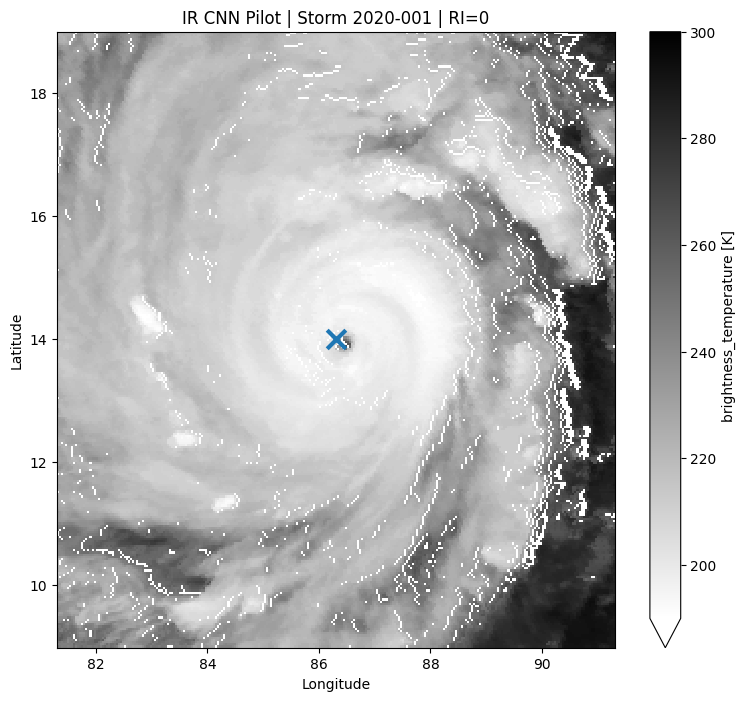

In [ ]:
# ============================================================
# STEP 3 — AUTOMATIC STORM-CENTERED IR CROP
# ============================================================

import matplotlib.pyplot as plt

# Use the IMD observation closest to the satellite time
row = pilot_obs.loc[
    pilot_obs["time_difference_minutes"].idxmin()
]

storm_lat = float(row["latitude"])
storm_lon = float(row["longitude"])
ri_label = int(row["RI_24h"])
storm_id = row["storm_id"]
obs_time = row["datetime_utc"]
sat_time = row["satellite_time"]

print("=" * 70)
print("CNN PILOT SAMPLE")
print("=" * 70)

print("Storm ID       :", storm_id)
print("IMD time       :", obs_time)
print("Satellite time :", sat_time)
print("Latitude       :", storm_lat)
print("Longitude      :", storm_lon)
print("RI label       :", ri_label)

# ------------------------------------------------------------
# Extract ±5° storm-centered region
# ------------------------------------------------------------

crop = ds["Tb"].sel(
    time=sat_time,
    lat=slice(storm_lat - 5, storm_lat + 5),
    lon=slice(storm_lon - 5, storm_lon + 5)
)

print("\nCrop shape:", crop.shape)

# ------------------------------------------------------------
# Visualize
# ------------------------------------------------------------

plt.figure(figsize=(9, 8))

crop.where(crop > 100).plot(
    cmap="gray_r",
    vmin=190,
    vmax=300
)

plt.scatter(
    storm_lon,
    storm_lat,
    marker="x",
    s=180,
    linewidths=3
)

plt.title(
    f"IR CNN Pilot | Storm {storm_id} | RI={ri_label}"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
# ============================================================
# STEP 5 — RESIZE TO 128 × 128
# ============================================================

import tensorflow as tf

image_128 = tf.image.resize(
    image_cnn,
    [128, 128]
).numpy().astype(np.float32)

print("=" * 70)
print("RESIZED CNN IMAGE")
print("=" * 70)

print("Shape:", image_128.shape)
print("Min :", image_128.min())
print("Max :", image_128.max())

print("=" * 70)
print("✅ 128 × 128 CNN SAMPLE READY")
print("=" * 70)

RESIZED CNN IMAGE
Shape: (128, 128, 1)
Min : 0.06955916
Max : 0.85714287
✅ 128 × 128 CNN SAMPLE READY


In [ ]:
# ============================================================
# STEP 6 — SAVE PILOT CNN SAMPLE
# ============================================================

import os
import numpy as np
import pandas as pd

os.makedirs("/content/satellite_cnn_pilot", exist_ok=True)

# Save image
np.save(
    "/content/satellite_cnn_pilot/2020-001_20200518_1200.npy",
    image_128
)

# Save label + metadata
metadata = pd.DataFrame([{
    "storm_id": storm_id,
    "datetime_utc": obs_time,
    "satellite_time": sat_time,
    "latitude": storm_lat,
    "longitude": storm_lon,
    "RI_24h": ri_label,
    "image_file": "2020-001_20200518_1200.npy"
}])

metadata.to_csv(
    "/content/satellite_cnn_pilot/metadata.csv",
    index=False
)

print("=" * 70)
print("PILOT SAVED")
print("=" * 70)

print("Image:")
print("/content/satellite_cnn_pilot/2020-001_20200518_1200.npy")

print("\nMetadata:")
print(metadata)

print("\nImage shape:", image_128.shape)

print("=" * 70)
print("✅ SATELLITE CNN PILOT DATASET READY")
print("=" * 70)

PILOT SAVED
Image:
/content/satellite_cnn_pilot/2020-001_20200518_1200.npy

Metadata:
   storm_id        datetime_utc                satellite_time  latitude  \
0  2020-001 2020-05-18 12:00:00 2020-05-18 11:30:00.000026880      14.0   

   longitude  RI_24h                  image_file  
0       86.3       0  2020-001_20200518_1200.npy  

Image shape: (128, 128, 1)
✅ SATELLITE CNN PILOT DATASET READY


In [ ]:
# ============================================================
# STEP 8 — CREATE SMALL BALANCED SATELLITE CNN PILOT
# ============================================================

import pandas as pd
import numpy as np

# Work from satellite-compatible observations
pilot_df = sat_df.copy()

# ------------------------------------------------------------
# 1. Separate RI and non-RI
# ------------------------------------------------------------

ri_cases = pilot_df[pilot_df["RI_24h"] == 1].copy()
nonri_cases = pilot_df[pilot_df["RI_24h"] == 0].copy()

print("=" * 70)
print("SATELLITE CNN PILOT SELECTION")
print("=" * 70)

print("Available RI cases    :", len(ri_cases))
print("Available non-RI cases:", len(nonri_cases))


# ------------------------------------------------------------
# 2. Use storms rather than random rows
# ------------------------------------------------------------
# This prevents the pilot from being dominated by a few storms.

ri_storms = (
    ri_cases["storm_id"]
    .drop_duplicates()
    .sample(
        n=min(20, ri_cases["storm_id"].nunique()),
        random_state=42
    )
)

ri_pilot = ri_cases[
    ri_cases["storm_id"].isin(ri_storms)
].copy()


# Pick up to one RI observation per selected storm
ri_pilot = (
    ri_pilot
    .sort_values(["storm_id", "datetime_utc"])
    .groupby("storm_id", group_keys=False)
    .head(1)
)


# ------------------------------------------------------------
# 3. Select non-RI cases from different storms
# ------------------------------------------------------------

available_nonri_storms = nonri_cases[
    ~nonri_cases["storm_id"].isin(ri_storms)
]["storm_id"].drop_duplicates()

n_nonri_storms = min(
    40,
    len(available_nonri_storms)
)

nonri_storms = available_nonri_storms.sample(
    n=n_nonri_storms,
    random_state=42
)

nonri_pilot = nonri_cases[
    nonri_cases["storm_id"].isin(nonri_storms)
].copy()

# One observation per storm
nonri_pilot = (
    nonri_pilot
    .sort_values(["storm_id", "datetime_utc"])
    .groupby("storm_id", group_keys=False)
    .head(1)
)


# ------------------------------------------------------------
# 4. Combine
# ------------------------------------------------------------

sat_pilot = pd.concat(
    [ri_pilot, nonri_pilot],
    ignore_index=True
)

sat_pilot = sat_pilot.sort_values(
    "datetime_utc"
).reset_index(drop=True)


# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

pilot_path = "/content/satellite_cnn_pilot_metadata.csv"

sat_pilot.to_csv(
    pilot_path,
    index=False
)


# ------------------------------------------------------------
# 6. Report
# ------------------------------------------------------------

print("\nPilot observations:", len(sat_pilot))
print("Pilot storms      :", sat_pilot["storm_id"].nunique())

print("\nLabels:")
print(sat_pilot["RI_24h"].value_counts())

print("\nRI storms:")
print(
    sat_pilot[sat_pilot["RI_24h"] == 1]["storm_id"]
    .nunique()
)

print("\nNon-RI storms:")
print(
    sat_pilot[sat_pilot["RI_24h"] == 0]["storm_id"]
    .nunique()
)

print("\nDate range:")
print(
    sat_pilot["datetime_utc"].min(),
    "→",
    sat_pilot["datetime_utc"].max()
)

print("\nSaved:")
print(pilot_path)

print("=" * 70)
print("✅ SATELLITE CNN PILOT METADATA READY")
print("=" * 70)

SATELLITE CNN PILOT SELECTION
Available RI cases    : 122
Available non-RI cases: 2323

Pilot observations: 60
Pilot storms      : 60

Labels:
RI_24h
0.0    40
1.0    20
Name: count, dtype: int64

RI storms:
20

Non-RI storms:
40

Date range:
1998-11-14 03:00:00 → 2025-11-25 03:00:00

Saved:
/content/satellite_cnn_pilot_metadata.csv
✅ SATELLITE CNN PILOT METADATA READY


In [ ]:
# ============================================================
# STEP 9 — BUILD SATELLITE DOWNLOAD MANIFEST
# ============================================================

import pandas as pd
import numpy as np
import os

pilot = pd.read_csv(
    "/content/satellite_cnn_pilot_metadata.csv",
    parse_dates=["datetime_utc"]
)

# ------------------------------------------------------------
# Satellite has half-hourly observations.
# Round each IMD time to the nearest 30 minutes.
# ------------------------------------------------------------

pilot["target_satellite_time"] = (
    pilot["datetime_utc"]
    .dt.round("30min")
)

# The Merged IR filename is hourly, so identify the
# corresponding hour.
pilot["satellite_date"] = (
    pilot["target_satellite_time"]
    .dt.strftime("%Y%m%d")
)

pilot["satellite_hour"] = (
    pilot["target_satellite_time"]
    .dt.strftime("%H")
)

# Expected filename pattern
pilot["expected_filename"] = (
    "merg_"
    + pilot["satellite_date"]
    + pilot["satellite_hour"]
    + "_4km-pixel.nc4"
)

# ------------------------------------------------------------
# Remove duplicate satellite files
# ------------------------------------------------------------

manifest = (
    pilot[
        [
            "storm_id",
            "datetime_utc",
            "latitude",
            "longitude",
            "RI_24h",
            "target_satellite_time",
            "expected_filename"
        ]
    ]
    .drop_duplicates("expected_filename")
    .sort_values("target_satellite_time")
    .reset_index(drop=True)
)

print("=" * 70)
print("SATELLITE DOWNLOAD MANIFEST")
print("=" * 70)

print("\nPilot observations:", len(pilot))
print("Unique satellite files needed:", len(manifest))

print("\nFirst files:")
print(
    manifest[
        [
            "storm_id",
            "datetime_utc",
            "target_satellite_time",
            "expected_filename",
            "RI_24h"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

print("\nLast files:")
print(
    manifest[
        [
            "storm_id",
            "datetime_utc",
            "target_satellite_time",
            "expected_filename",
            "RI_24h"
        ]
    ]
    .tail(10)
    .to_string(index=False)
)

# Save manifest
manifest_path = "/content/satellite_cnn_download_manifest.csv"

manifest.to_csv(
    manifest_path,
    index=False
)

print("\nSaved:")
print(manifest_path)

print("=" * 70)
print("✅ DOWNLOAD MANIFEST CREATED")
print("=" * 70)

SATELLITE DOWNLOAD MANIFEST

Pilot observations: 60
Unique satellite files needed: 60

First files:
storm_id        datetime_utc target_satellite_time             expected_filename  RI_24h
1998-008 1998-11-14 03:00:00   1998-11-14 03:00:00 merg_1998111403_4km-pixel.nc4     1.0
1999-001 1999-02-01 03:00:00   1999-02-01 03:00:00 merg_1999020103_4km-pixel.nc4     0.0
1999-006 1999-10-15 18:00:00   1999-10-15 18:00:00 merg_1999101518_4km-pixel.nc4     1.0
1999-007 1999-10-27 06:00:00   1999-10-27 06:00:00 merg_1999102706_4km-pixel.nc4     1.0
2000-004 2000-10-25 12:00:00   2000-10-25 12:00:00 merg_2000102512_4km-pixel.nc4     0.0
2000-005 2000-11-27 06:00:00   2000-11-27 06:00:00 merg_2000112706_4km-pixel.nc4     1.0
2000-006 2000-12-24 18:00:00   2000-12-24 18:00:00 merg_2000122418_4km-pixel.nc4     1.0
2001-002 2001-06-12 03:00:00   2001-06-12 03:00:00 merg_2001061203_4km-pixel.nc4     0.0
2001-005 2001-10-14 12:00:00   2001-10-14 12:00:00 merg_2001101412_4km-pixel.nc4     0.0
2002-002 2

In [ ]:
# ============================================================
# STEP 11 — CREATE STORM-CENTERED CNN SAMPLE
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import os

from PIL import Image

print("=" * 70)
print("CREATING STORM-CENTERED IR CNN SAMPLE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Find the IMD observation
# ------------------------------------------------------------

storm_id = "1998-008"

row = sat_pilot[
    sat_pilot["storm_id"].astype(str) == storm_id
].iloc[0]

storm_time = pd.to_datetime(row["datetime_utc"])
storm_lat = float(row["latitude"])
storm_lon = float(row["longitude"])
label = int(row["RI_24h"])

print("\nStorm ID :", storm_id)
print("IMD time :", storm_time)
print("Latitude:", storm_lat)
print("Longitude:", storm_lon)
print("RI label:", label)


# ------------------------------------------------------------
# 2. Open satellite file
# ------------------------------------------------------------

nc_file = "/content/merg_1998111403_4km-pixel.nc4"

ds = xr.open_dataset(nc_file)

print("\nSatellite times:")
print(ds["time"].values)


# ------------------------------------------------------------
# 3. Select nearest satellite image
# ------------------------------------------------------------

sat_time = pd.Timestamp(
    ds["time"]
    .sel(time=storm_time, method="nearest")
    .values
)

print("\nSelected satellite time:", sat_time)

time_difference = abs(
    (sat_time - storm_time).total_seconds()
) / 60

print(
    "Time difference:",
    time_difference,
    "minutes"
)


# ------------------------------------------------------------
# 4. Extract brightness temperature
# ------------------------------------------------------------

tb = ds["Tb"].sel(
    time=sat_time,
    method="nearest"
)


# ------------------------------------------------------------
# 5. Storm-centered crop
# ------------------------------------------------------------
# ±5 degrees around cyclone center.
#
# At ~4 km resolution this gives roughly:
# 10° × 10° ≈ 275 × 275 pixels

lat_min = storm_lat - 5
lat_max = storm_lat + 5

lon_min = storm_lon - 5
lon_max = storm_lon + 5

crop = tb.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

print("\nCrop:")
print("Latitude :", lat_min, "→", lat_max)
print("Longitude:", lon_min, "→", lon_max)
print("Crop shape:", crop.shape)


# ------------------------------------------------------------
# 6. Convert to numpy
# ------------------------------------------------------------

crop_np = crop.values.astype(np.float32)

# Replace invalid values
crop_np[~np.isfinite(crop_np)] = np.nan

print(
    "Tb range:",
    np.nanmin(crop_np),
    "→",
    np.nanmax(crop_np),
    "K"
)


# ------------------------------------------------------------
# 7. Replace missing values
# ------------------------------------------------------------

# Use 300 K for missing pixels.
# 300 K represents a warm/cloud-free background.

crop_np = np.nan_to_num(
    crop_np,
    nan=300.0,
    posinf=300.0,
    neginf=300.0
)


# ------------------------------------------------------------
# 8. Normalize brightness temperature
# ------------------------------------------------------------
# Physical range used for CNN:
#
# 180 K = very cold cloud tops
# 300 K = warm surface / cloud-free region
#
# Cold clouds therefore remain clearly represented.

crop_np = np.clip(
    crop_np,
    180,
    300
)

crop_norm = (
    300.0 - crop_np
) / (
    300.0 - 180.0
)


# ------------------------------------------------------------
# 9. Resize to 128 × 128
# ------------------------------------------------------------

image = Image.fromarray(
    (crop_norm * 255).astype(np.uint8)
)

image = image.resize(
    (128, 128),
    Image.Resampling.BILINEAR
)

image_128 = (
    np.asarray(image)
    .astype(np.float32) / 255.0
)

# CNN expects:
# (height, width, channels)

image_128 = image_128[..., np.newaxis]


# ------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------

output_dir = "/content/satellite_cnn_pilot"

os.makedirs(
    output_dir,
    exist_ok=True
)

output_file = os.path.join(
    output_dir,
    f"{storm_id}_{storm_time.strftime('%Y%m%d_%H%M')}.npy"
)

np.save(
    output_file,
    image_128
)


# ------------------------------------------------------------
# 11. Save metadata
# ------------------------------------------------------------

metadata = pd.DataFrame([{
    "storm_id": storm_id,
    "datetime_utc": storm_time,
    "satellite_time": sat_time,
    "time_difference_minutes": time_difference,
    "latitude": storm_lat,
    "longitude": storm_lon,
    "RI_24h": label,
    "image_file": output_file,
    "image_height": 128,
    "image_width": 128,
    "channels": 1
}])

metadata_file = os.path.join(
    output_dir,
    "metadata_1998_sample.csv"
)

metadata.to_csv(
    metadata_file,
    index=False
)


print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

print("Original crop:", crop.shape)
print("CNN image    :", image_128.shape)
print("RI label     :", label)
print("Satellite Δt :", time_difference, "minutes")

print("\nImage saved:")
print(output_file)

print("\nMetadata saved:")
print(metadata_file)

print("=" * 70)
print("✅ 1998 SATELLITE CNN SAMPLE CREATED")
print("=" * 70)

CREATING STORM-CENTERED IR CNN SAMPLE

Storm ID : 1998-008
IMD time : 1998-11-14 03:00:00
Latitude: 13.5
Longitude: 86.5
RI label: 1

Satellite times:
['1998-11-14T03:00:00.000000000' '1998-11-14T03:30:00.000013440']

Selected satellite time: 1998-11-14 03:00:00
Time difference: 0.0 minutes

Crop:
Latitude : 8.5 → 18.5
Longitude: 81.5 → 91.5
Crop shape: (274, 275)
Tb range: 182.0 → 298.0 K

RESULT
Original crop: (274, 275)
CNN image    : (128, 128, 1)
RI label     : 1
Satellite Δt : 0.0 minutes

Image saved:
/content/satellite_cnn_pilot/1998-008_19981114_0300.npy

Metadata saved:
/content/satellite_cnn_pilot/metadata_1998_sample.csv
✅ 1998 SATELLITE CNN SAMPLE CREATED


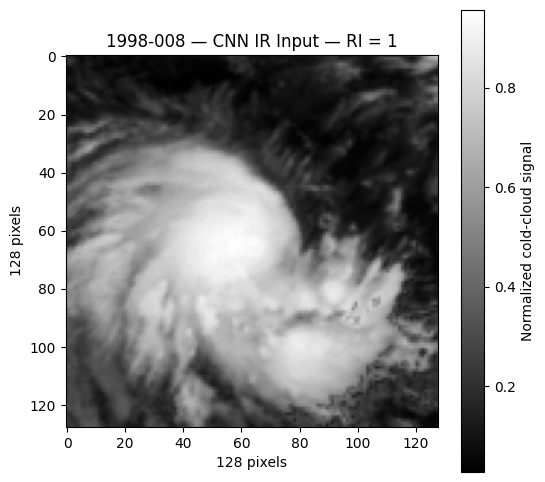

Shape: (128, 128, 1)
Min: 0.02745098
Max: 0.95686275


In [ ]:
# ============================================================
# STEP 12 — VISUAL CHECK OF CNN INPUT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

img = np.load(
    "/content/satellite_cnn_pilot/1998-008_19981114_0300.npy"
)

plt.figure(figsize=(6, 6))

plt.imshow(
    img[:, :, 0],
    cmap="gray"
)

plt.title("1998-008 — CNN IR Input — RI = 1")
plt.xlabel("128 pixels")
plt.ylabel("128 pixels")
plt.colorbar(label="Normalized cold-cloud signal")

plt.show()

print("Shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving merg_2020051719_4km-pixel.nc4 to merg_2020051719_4km-pixel.nc4


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
from PIL import Image

# ============================================================
# SETTINGS
# ============================================================

NC_DIR = "/content"
OUT_DIR = "/content/satellite_cnn_pilot"

os.makedirs(OUT_DIR, exist_ok=True)

IMD_FILE = "/content/IMD_BoB_RI_training_base-2.csv"

CROP_DEG = 5.0
CNN_SIZE = 128
MAX_TIME_DIFF_MIN = 90

# ============================================================
# LOAD IMD DATA
# ============================================================

imd = pd.read_csv(IMD_FILE)

imd["datetime_utc"] = pd.to_datetime(
    imd["datetime_utc"],
    errors="coerce"
)

imd = imd.dropna(
    subset=["datetime_utc", "latitude", "longitude", "RI_24h"]
).copy()

print("=" * 70)
print("IMD DATA")
print("=" * 70)

print("Rows:", len(imd))
print("Storms:", imd["storm_id"].nunique())

# ============================================================
# FIND NC4 FILES
# ============================================================

nc_files = sorted(glob.glob(f"{NC_DIR}/*.nc4"))

print("\nNC4 files:", len(nc_files))

# ============================================================
# PROCESS FILES
# ============================================================

records = []

for nc_path in nc_files:

    filename = os.path.basename(nc_path)

    print("\n" + "-" * 70)
    print("FILE:", filename)

    # --------------------------------------------------------
    # Open dataset
    # --------------------------------------------------------

    try:
        ds = xr.open_dataset(nc_path)

        sat_time = pd.Timestamp(ds.time.values[0])

        print("Satellite time:", sat_time)

        # ----------------------------------------------------
        # Find nearest IMD observation
        # ----------------------------------------------------

        time_diff = (
            np.abs(
                (imd["datetime_utc"] - sat_time)
                .dt.total_seconds()
            ) / 60
        )

        nearest_idx = time_diff.idxmin()

        obs = imd.loc[nearest_idx]

        diff_min = time_diff.loc[nearest_idx]

        print("Nearest IMD time:", obs["datetime_utc"])
        print("Difference:", round(diff_min, 1), "minutes")

        # Ignore files that cannot be safely matched
        if diff_min > MAX_TIME_DIFF_MIN:

            print("⚠️ Too far from IMD observation — skipped")
            ds.close()
            continue

        storm_id = str(obs["storm_id"])
        obs_time = obs["datetime_utc"]

        lat = float(obs["latitude"])
        lon = float(obs["longitude"])
        label = int(obs["RI_24h"])

        print("Storm:", storm_id)
        print("Center:", lat, lon)
        print("RI:", label)

        # ----------------------------------------------------
        # Get brightness temperature
        # ----------------------------------------------------

        tb = ds["Tb"]

        # First satellite image in the file
        tb0 = tb.isel(time=0)

        # ----------------------------------------------------
        # Storm-centered crop
        # ----------------------------------------------------

        lat_min = lat - CROP_DEG
        lat_max = lat + CROP_DEG

        lon_min = lon - CROP_DEG
        lon_max = lon + CROP_DEG

        crop = tb0.sel(
            lat=slice(lat_min, lat_max),
            lon=slice(lon_min, lon_max)
        )

        arr = crop.values.astype(np.float32)

        # ----------------------------------------------------
        # Remove invalid values
        # ----------------------------------------------------

        arr[~np.isfinite(arr)] = np.nan

        valid = np.isfinite(arr)

        if valid.sum() < 100:

            print("⚠️ Not enough valid pixels — skipped")
            ds.close()
            continue

        # ----------------------------------------------------
        # Fill missing pixels using median
        # ----------------------------------------------------

        median_tb = np.nanmedian(arr)

        arr = np.where(
            np.isfinite(arr),
            arr,
            median_tb
        )

        # ----------------------------------------------------
        # Convert Tb → normalized cold-cloud signal
        #
        # Lower Tb = colder cloud tops = stronger convection
        # ----------------------------------------------------

        arr = np.clip(arr, 180, 310)

        cold_signal = 1.0 - (
            (arr - 180.0) / (310.0 - 180.0)
        )

        cold_signal = np.clip(
            cold_signal,
            0,
            1
        )

        # ----------------------------------------------------
        # Resize to CNN input
        # ----------------------------------------------------

        image = Image.fromarray(
            (cold_signal * 255).astype(np.uint8)
        )

        image = image.resize(
            (CNN_SIZE, CNN_SIZE),
            Image.Resampling.BILINEAR
        )

        cnn_image = (
            np.asarray(image).astype(np.float32) / 255.0
        )

        cnn_image = cnn_image[..., np.newaxis]

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        safe_time = obs_time.strftime("%Y%m%d_%H%M")

        output_name = (
            f"{storm_id}_{safe_time}.npy"
        )

        output_path = os.path.join(
            OUT_DIR,
            output_name
        )

        np.save(
            output_path,
            cnn_image
        )

        print("Crop:", arr.shape)
        print("CNN:", cnn_image.shape)
        print("Saved:", output_name)

        records.append({
            "storm_id": storm_id,
            "datetime_utc": obs_time,
            "satellite_time": sat_time,
            "time_difference_minutes": diff_min,
            "latitude": lat,
            "longitude": lon,
            "RI_24h": label,
            "image_file": output_name
        })

        ds.close()

    except Exception as e:

        print("❌ ERROR:", e)

# ============================================================
# SAVE METADATA
# ============================================================

new_metadata = pd.DataFrame(records)

metadata_path = os.path.join(
    OUT_DIR,
    "metadata_all.csv"
)

new_metadata.to_csv(
    metadata_path,
    index=False
)

print("\n")
print("=" * 70)
print("CNN IMAGE CREATION COMPLETE")
print("=" * 70)

print("New images:", len(new_metadata))

if len(new_metadata) > 0:

    print("\nRI distribution:")
    print(
        new_metadata["RI_24h"]
        .value_counts()
        .sort_index()
    )

    print("\nStorms:")
    print(
        new_metadata["storm_id"].nunique()
    )

print("\nMetadata:")
print(metadata_path)

IMD DATA
Rows: 3198
Storms: 258

NC4 files: 9

----------------------------------------------------------------------
FILE: merg_1998111403_4km-pixel.nc4
Satellite time: 1998-11-14 03:00:00
Nearest IMD time: 1998-11-14 03:00:00
Difference: 0.0 minutes
Storm: 1998-008
Center: 13.5 86.5
RI: 1
Crop: (274, 275)
CNN: (128, 128, 1)
Saved: 1998-008_19981114_0300.npy

----------------------------------------------------------------------
FILE: merg_2000102512_4km-pixel.nc4
Satellite time: 2000-10-25 12:00:00
Nearest IMD time: 2000-10-25 12:00:00
Difference: 0.0 minutes
Storm: 2000-004
Center: 14.0 92.5
RI: 0
Crop: (275, 275)
CNN: (128, 128, 1)
Saved: 2000-004_20001025_1200.npy

----------------------------------------------------------------------
FILE: merg_2000112706_4km-pixel.nc4
Satellite time: 2000-11-27 06:00:00
Nearest IMD time: 2000-11-27 06:00:00
Difference: 0.0 minutes
Storm: 2000-005
Center: 11.0 87.0
RI: 1
Crop: (275, 275)
CNN: (128, 128, 1)
Saved: 2000-005_20001127_0600.npy

-----

In [ ]:
import os
import pandas as pd

META = "/content/satellite_cnn_pilot/metadata_all.csv"

df = pd.read_csv(META)

print("=" * 70)
print("BEFORE CLEANING")
print("=" * 70)

print("Rows:", len(df))
print("Unique images:", df["image_file"].nunique())
print("Unique storms:", df["storm_id"].nunique())

# Remove duplicate image filenames
df = df.drop_duplicates(
    subset=["image_file"],
    keep="first"
).reset_index(drop=True)

# Save cleaned metadata
clean_path = "/content/satellite_cnn_pilot/metadata_clean.csv"
df.to_csv(clean_path, index=False)

print("\n" + "=" * 70)
print("CLEAN CNN DATASET")
print("=" * 70)

print("Images:", len(df))
print("Storms:", df["storm_id"].nunique())

print("\nRI distribution:")
print(df["RI_24h"].value_counts().sort_index())

print("\nSamples:")
print(
    df[
        [
            "storm_id",
            "datetime_utc",
            "RI_24h",
            "image_file"
        ]
    ].to_string(index=False)
)

print("\nSaved:")
print(clean_path)

BEFORE CLEANING
Rows: 9
Unique images: 7
Unique storms: 5

CLEAN CNN DATASET
Images: 7
Storms: 5

RI distribution:
RI_24h
0    4
1    3
Name: count, dtype: int64

Samples:
storm_id        datetime_utc  RI_24h                 image_file
1998-008 1998-11-14 03:00:00       1 1998-008_19981114_0300.npy
2000-004 2000-10-25 12:00:00       0 2000-004_20001025_1200.npy
2000-005 2000-11-27 06:00:00       1 2000-005_20001127_0600.npy
2000-006 2000-12-24 06:00:00       0 2000-006_20001224_0600.npy
2020-001 2020-05-17 18:00:00       1 2020-001_20200517_1800.npy
2020-001 2020-05-18 03:00:00       0 2020-001_20200518_0300.npy
2020-001 2020-05-18 12:00:00       0 2020-001_20200518_1200.npy

Saved:
/content/satellite_cnn_pilot/metadata_clean.csv


In [ ]:
# ============================================================
# SATELLITE IR CNN — MVP PILOT
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# SETTINGS
# ============================================================

DATA_DIR = "/content/satellite_cnn_pilot"
META_FILE = os.path.join(DATA_DIR, "metadata_clean.csv")

IMG_SIZE = 128
BATCH_SIZE = 2
EPOCHS = 30

# ============================================================
# LOAD METADATA
# ============================================================

df = pd.read_csv(META_FILE)

print("=" * 70)
print("CNN PILOT DATASET")
print("=" * 70)

print("Images:", len(df))
print("Storms:", df["storm_id"].nunique())

print("\nRI distribution:")
print(df["RI_24h"].value_counts().sort_index())

# ============================================================
# STORM-SAFE SPLIT
# ============================================================

# Keep the entire 2020 storm out of training.
# This prevents storm-level data leakage.

TEST_STORM = "2020-001"

train_df = df[df["storm_id"] != TEST_STORM].copy()
test_df = df[df["storm_id"] == TEST_STORM].copy()

print("\n" + "=" * 70)
print("STORM-SAFE SPLIT")
print("=" * 70)

print("Training images:", len(train_df))
print("Testing images :", len(test_df))

print("\nTraining storms:")
print(train_df["storm_id"].unique())

print("\nTesting storm:")
print(test_df["storm_id"].unique())

print("\nTraining labels:")
print(train_df["RI_24h"].value_counts().sort_index())

print("\nTesting labels:")
print(test_df["RI_24h"].value_counts().sort_index())

# ============================================================
# LOAD IMAGES
# ============================================================

def load_images(metadata):

    X = []
    y = []

    for _, row in metadata.iterrows():

        path = os.path.join(
            DATA_DIR,
            row["image_file"]
        )

        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Image not found: {path}"
            )

        image = np.load(path)

        if image.shape != (128, 128, 1):
            raise ValueError(
                f"Unexpected image shape {image.shape}: {path}"
            )

        X.append(image)
        y.append(int(row["RI_24h"]))

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32)
    )


X_train, y_train = load_images(train_df)
X_test, y_test = load_images(test_df)

print("\n" + "=" * 70)
print("IMAGE ARRAYS")
print("=" * 70)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

# ============================================================
# CLASS WEIGHTS
# ============================================================

n_negative = np.sum(y_train == 0)
n_positive = np.sum(y_train == 1)

class_weight = {
    0: 1.0,
    1: float(n_negative / max(n_positive, 1))
}

print("\nClass weights:")
print(class_weight)

# ============================================================
# BUILD SMALL CNN
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(128, 128, 1)
    ),

    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(
        0.30
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print("\n" + "=" * 70)
print("CNN ARCHITECTURE")
print("=" * 70)

model.summary()

# ============================================================
# TRAIN
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=7,
    restore_best_weights=True
)

print("\n" + "=" * 70)
print("TRAINING CNN")
print("=" * 70)

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ CNN TRAINING COMPLETE")

# ============================================================
# PREDICT
# ============================================================

prob = model.predict(
    X_test,
    verbose=0
).ravel()

pred = (
    prob >= 0.5
).astype(int)

# ============================================================
# EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("CNN PILOT TEST RESULTS")
print("=" * 70)

if len(np.unique(y_test)) == 2:

    roc = roc_auc_score(
        y_test,
        prob
    )

    pr = average_precision_score(
        y_test,
        prob
    )

    print(f"ROC-AUC : {roc:.4f}")
    print(f"PR-AUC  : {pr:.4f}")

else:

    print("ROC-AUC : cannot calculate")
    print("PR-AUC  : cannot calculate")

precision = precision_score(
    y_test,
    pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        pred
    )
)

# ============================================================
# SHOW PREDICTIONS
# ============================================================

results = test_df[
    [
        "storm_id",
        "datetime_utc",
        "RI_24h",
        "image_file"
    ]
].copy()

results["P_RI"] = prob
results["prediction"] = pred

print("\n" + "=" * 70)
print("PREDICTIONS")
print("=" * 70)

print(
    results.to_string(index=False)
)

# ============================================================
# SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    DATA_DIR,
    "satellite_ir_cnn_mvp.keras"
)

model.save(MODEL_PATH)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(MODEL_PATH)

CNN PILOT DATASET
Images: 7
Storms: 5

RI distribution:
RI_24h
0    4
1    3
Name: count, dtype: int64

STORM-SAFE SPLIT
Training images: 4
Testing images : 3

Training storms:
['1998-008' '2000-004' '2000-005' '2000-006']

Testing storm:
['2020-001']

Training labels:
RI_24h
0    2
1    2
Name: count, dtype: int64

Testing labels:
RI_24h
0    2
1    1
Name: count, dtype: int64

IMAGE ARRAYS
X_train: (4, 128, 128, 1)
y_train: (4,)
X_test : (3, 128, 128, 1)
y_test : (3,)

Class weights:
{0: 1.0, 1: 1.0}

CNN ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING CNN
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.6940 - pr_auc: 0.4507 - roc_auc: 0.5000
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.6897 - pr_auc: 0.7500 - roc_auc: 0.6250
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.6806 - pr_auc: 1.0000 - roc_auc: 1.0000
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.7043 - pr_auc: 0.3069 - roc_auc: 0.0000e+00
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.6792 - pr_auc: 0.6667 - roc_auc: 0.7500
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.7203 - pr_auc: 0.3069 - roc_auc: 0.0000e+00
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.7071 - pr_auc: 0.3069 - roc_auc: 0.0000e+00
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.6934 - pr_auc: 0.5000 - roc_auc: 0.5000
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.6918 - pr_auc: 0.8207 - roc_auc: 0.7500
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.7123 - pr_auc

In [ ]:
from google.colab import files
import os

print("Select your satellite .nc4 files to upload")

uploaded = files.upload()

print("\n" + "=" * 70)
print("UPLOAD COMPLETE")
print("=" * 70)

for filename in uploaded.keys():
    print("✓", filename)

print("\nTotal uploaded:", len(uploaded))

print("\nFiles currently in /content:")
nc4_files = [
    f for f in os.listdir("/content")
    if f.lower().endswith(".nc4")
]

for f in sorted(nc4_files):
    print("✓", f)

print("\nTotal NC4 files:", len(nc4_files))

Select your satellite .nc4 files to upload


Saving merg_2005091203_4km-pixel.nc4 to merg_2005091203_4km-pixel.nc4
Saving merg_1999020103_4km-pixel.nc4 to merg_1999020103_4km-pixel.nc4
Saving merg_1999101518_4km-pixel.nc4 to merg_1999101518_4km-pixel.nc4
Saving merg_1999102706_4km-pixel.nc4 to merg_1999102706_4km-pixel.nc4
Saving merg_2001101412_4km-pixel.nc4 to merg_2001101412_4km-pixel.nc4
Saving merg_2003072503_4km-pixel.nc4 to merg_2003072503_4km-pixel.nc4
Saving merg_2003082712_4km-pixel.nc4 to merg_2003082712_4km-pixel.nc4
Saving merg_2004051800_4km-pixel.nc4 to merg_2004051800_4km-pixel.nc4
Saving merg_2005072903_4km-pixel.nc4 to merg_2005072903_4km-pixel.nc4
Saving merg_2005112803_4km-pixel.nc4 to merg_2005112803_4km-pixel.nc4
Saving merg_2022081900_4km-pixel.nc4 to merg_2022081900_4km-pixel.nc4
Saving merg_2023013003_4km-pixel.nc4 to merg_2023013003_4km-pixel.nc4
Saving merg_2023051100_4km-pixel.nc4 to merg_2023051100_4km-pixel.nc4
Saving merg_2023080100_4km-pixel.nc4 to merg_2023080100_4km-pixel.nc4
Saving merg_20231023

In [ ]:
# ============================================================
# CREATE CNN DATASET FROM ALL CURRENT NC4 FILES
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
from PIL import Image

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

NC_DIR = "/content"
OUT_DIR = "/content/satellite_cnn_pilot"
IMD_FILE = "/content/IMD_BoB_RI_training_base-2.csv"

os.makedirs(OUT_DIR, exist_ok=True)

CROP_DEG = 5.0
CNN_SIZE = 128
MAX_TIME_DIFF_MIN = 90

# ------------------------------------------------------------
# LOAD IMD
# ------------------------------------------------------------

imd = pd.read_csv(IMD_FILE)

imd["datetime_utc"] = pd.to_datetime(
    imd["datetime_utc"],
    errors="coerce"
)

imd = imd.dropna(
    subset=[
        "datetime_utc",
        "latitude",
        "longitude",
        "RI_24h"
    ]
).copy()

print("=" * 70)
print("IMD DATA")
print("=" * 70)

print("Rows:", len(imd))
print("Storms:", imd["storm_id"].nunique())

# ------------------------------------------------------------
# FIND NC4 FILES
# ------------------------------------------------------------

nc_files = sorted(
    glob.glob("/content/*.nc4")
)

print("\nNC4 files found:", len(nc_files))

# ------------------------------------------------------------
# PROCESS
# ------------------------------------------------------------

records = []

for i, nc_path in enumerate(nc_files, 1):

    filename = os.path.basename(nc_path)

    print("\n" + "=" * 70)
    print(f"[{i}/{len(nc_files)}] {filename}")
    print("=" * 70)

    try:

        ds = xr.open_dataset(nc_path)

        sat_time = pd.Timestamp(
            ds.time.values[0]
        )

        # Find nearest IMD observation
        time_diff = (
            np.abs(
                (
                    imd["datetime_utc"]
                    - sat_time
                ).dt.total_seconds()
            ) / 60
        )

        idx = time_diff.idxmin()
        obs = imd.loc[idx]

        diff_min = float(time_diff.loc[idx])

        print("Satellite time :", sat_time)
        print("IMD time       :", obs["datetime_utc"])
        print("Time difference:", round(diff_min, 1), "min")

        if diff_min > MAX_TIME_DIFF_MIN:

            print("⚠️ Too far from IMD — skipped")
            ds.close()
            continue

        storm_id = str(obs["storm_id"])
        obs_time = pd.Timestamp(
            obs["datetime_utc"]
        )

        lat = float(obs["latitude"])
        lon = float(obs["longitude"])
        label = int(obs["RI_24h"])

        print("Storm:", storm_id)
        print("Center:", lat, lon)
        print("RI:", label)

        # ----------------------------------------------------
        # READ Tb
        # ----------------------------------------------------

        tb = ds["Tb"].isel(time=0)

        # ----------------------------------------------------
        # STORM CENTERED CROP
        # ----------------------------------------------------

        crop = tb.sel(
            lat=slice(
                lat - CROP_DEG,
                lat + CROP_DEG
            ),
            lon=slice(
                lon - CROP_DEG,
                lon + CROP_DEG
            )
        )

        arr = crop.values.astype(
            np.float32
        )

        # ----------------------------------------------------
        # VALID VALUES
        # ----------------------------------------------------

        arr[~np.isfinite(arr)] = np.nan

        if np.sum(np.isfinite(arr)) < 100:

            print("⚠️ Not enough valid pixels — skipped")
            ds.close()
            continue

        median_tb = np.nanmedian(arr)

        arr = np.where(
            np.isfinite(arr),
            arr,
            median_tb
        )

        # ----------------------------------------------------
        # NORMALIZE Tb
        #
        # 180 K = very cold cloud tops
        # 310 K = warm surface/cloud-free region
        #
        # Lower Tb → higher CNN signal
        # ----------------------------------------------------

        arr = np.clip(
            arr,
            180,
            310
        )

        normalized = 1.0 - (
            (arr - 180.0) /
            (310.0 - 180.0)
        )

        normalized = np.clip(
            normalized,
            0,
            1
        )

        # ----------------------------------------------------
        # RESIZE
        # ----------------------------------------------------

        image = Image.fromarray(
            (normalized * 255).astype(
                np.uint8
            )
        )

        image = image.resize(
            (CNN_SIZE, CNN_SIZE),
            Image.Resampling.BILINEAR
        )

        cnn_image = (
            np.asarray(image)
            .astype(np.float32)
            / 255.0
        )

        cnn_image = cnn_image[
            ..., np.newaxis
        ]

        # ----------------------------------------------------
        # UNIQUE OUTPUT NAME
        # ----------------------------------------------------

        safe_time = obs_time.strftime(
            "%Y%m%d_%H%M"
        )

        output_name = (
            f"{storm_id}_{safe_time}.npy"
        )

        output_path = os.path.join(
            OUT_DIR,
            output_name
        )

        # Don't overwrite/recreate duplicate image
        if os.path.exists(output_path):

            print("⚠️ Image already exists:", output_name)

        else:

            np.save(
                output_path,
                cnn_image
            )

            print(
                "✅ Saved:",
                output_name
            )

        records.append({
            "storm_id": storm_id,
            "datetime_utc": obs_time,
            "satellite_time": sat_time,
            "time_difference_minutes": diff_min,
            "latitude": lat,
            "longitude": lon,
            "RI_24h": label,
            "image_file": output_name
        })

        ds.close()

    except Exception as e:

        print(
            "❌ ERROR:",
            repr(e)
        )

# ------------------------------------------------------------
# METADATA
# ------------------------------------------------------------

metadata = pd.DataFrame(records)

if len(metadata) > 0:

    metadata = metadata.drop_duplicates(
        subset=["image_file"],
        keep="first"
    ).reset_index(drop=True)

metadata_path = os.path.join(
    OUT_DIR,
    "metadata_27_clean.csv"
)

metadata.to_csv(
    metadata_path,
    index=False
)

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SATELLITE CNN MVP DATASET")
print("=" * 70)

print("Unique CNN images:", len(metadata))

if len(metadata) > 0:

    print(
        "Unique storms:",
        metadata["storm_id"].nunique()
    )

    print("\nRI distribution:")
    print(
        metadata["RI_24h"]
        .value_counts()
        .sort_index()
    )

    print("\nSamples:")
    print(
        metadata[
            [
                "storm_id",
                "datetime_utc",
                "RI_24h",
                "image_file"
            ]
        ].to_string(index=False)
    )

print("\nMetadata saved:")
print(metadata_path)

print("\n✅ CNN IMAGE GENERATION COMPLETE")

IMD DATA
Rows: 3198
Storms: 258

NC4 files found: 27

[1/27] merg_1998111403_4km-pixel.nc4
Satellite time : 1998-11-14 03:00:00
IMD time       : 1998-11-14 03:00:00
Time difference: 0.0 min
Storm: 1998-008
Center: 13.5 86.5
RI: 1
⚠️ Image already exists: 1998-008_19981114_0300.npy

[2/27] merg_1999020103_4km-pixel.nc4
Satellite time : 1999-02-01 03:00:00
IMD time       : 1999-02-01 03:00:00
Time difference: 0.0 min
Storm: 1999-001
Center: 9.0 89.0
RI: 0
✅ Saved: 1999-001_19990201_0300.npy

[3/27] merg_1999101518_4km-pixel.nc4
Satellite time : 1999-10-15 18:00:00
IMD time       : 1999-10-15 18:00:00
Time difference: 0.0 min
Storm: 1999-006
Center: 15.2 89.5
RI: 1
✅ Saved: 1999-006_19991015_1800.npy

[4/27] merg_1999102706_4km-pixel.nc4
Satellite time : 1999-10-27 06:00:00
IMD time       : 1999-10-27 06:00:00
Time difference: 0.0 min
Storm: 1999-007
Center: 16.5 91.5
RI: 1
✅ Saved: 1999-007_19991027_0600.npy

[5/27] merg_2000102512_4km-pixel.nc4
Satellite time : 2000-10-25 12:00:00
IMD t

In [ ]:
# ============================================================
# SATELLITE IR CNN — 25 IMAGE MVP
# STORM-SAFE TRAIN / VALIDATION / TEST
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# SETTINGS
# ============================================================

DATA_DIR = "/content/satellite_cnn_pilot"
META_FILE = os.path.join(
    DATA_DIR,
    "metadata_27_clean.csv"
)

IMG_SIZE = 128
BATCH_SIZE = 4
EPOCHS = 40

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(META_FILE)

print("=" * 70)
print("SATELLITE CNN MVP DATASET")
print("=" * 70)

print("Images :", len(df))
print("Storms :", df["storm_id"].nunique())

print("\nRI distribution:")
print(df["RI_24h"].value_counts().sort_index())

# ============================================================
# STORM-LEVEL SPLIT
# ============================================================

storms = df["storm_id"].unique()

rng = np.random.RandomState(42)
rng.shuffle(storms)

# Approximate:
# 60% train
# 20% validation
# 20% test

n_storms = len(storms)

n_train = int(n_storms * 0.60)
n_val = int(n_storms * 0.20)

train_storms = storms[:n_train]
val_storms = storms[n_train:n_train + n_val]
test_storms = storms[n_train + n_val:]

train_df = df[
    df["storm_id"].isin(train_storms)
].copy()

val_df = df[
    df["storm_id"].isin(val_storms)
].copy()

test_df = df[
    df["storm_id"].isin(test_storms)
].copy()

print("\n" + "=" * 70)
print("STORM-SAFE SPLIT")
print("=" * 70)

print(
    f"TRAIN: {len(train_df)} images | "
    f"{train_df['storm_id'].nunique()} storms"
)

print(
    f"VALID: {len(val_df)} images | "
    f"{val_df['storm_id'].nunique()} storms"
)

print(
    f"TEST : {len(test_df)} images | "
    f"{test_df['storm_id'].nunique()} storms"
)

print("\nTrain RI:")
print(train_df["RI_24h"].value_counts().sort_index())

print("\nValidation RI:")
print(val_df["RI_24h"].value_counts().sort_index())

print("\nTest RI:")
print(test_df["RI_24h"].value_counts().sort_index())

# Check leakage
assert len(
    set(train_storms) &
    set(val_storms)
) == 0

assert len(
    set(train_storms) &
    set(test_storms)
) == 0

assert len(
    set(val_storms) &
    set(test_storms)
) == 0

print("\n✅ No storm leakage")

# ============================================================
# LOAD IMAGES
# ============================================================

def load_images(metadata):

    X = []
    y = []

    for _, row in metadata.iterrows():

        path = os.path.join(
            DATA_DIR,
            row["image_file"]
        )

        image = np.load(path)

        if image.shape != (128, 128, 1):
            raise ValueError(
                f"Bad shape {image.shape}: {path}"
            )

        X.append(image)
        y.append(int(row["RI_24h"]))

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32)
    )


X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print("\n" + "=" * 70)
print("IMAGE ARRAYS")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

# ============================================================
# CLASS WEIGHTS
# ============================================================

negative = np.sum(y_train == 0)
positive = np.sum(y_train == 1)

class_weight = {
    0: 1.0,
    1: float(negative / max(positive, 1))
}

print("\nClass weights:")
print(class_weight)

# ============================================================
# CNN
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(128, 128, 1)
    ),

    layers.Conv2D(
        16,
        3,
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2),

    layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2),

    layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.30),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print("\n" + "=" * 70)
print("CNN")
print("=" * 70)

model.summary()

# ============================================================
# TRAIN
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ CNN TRAINING COMPLETE")

# ============================================================
# TEST PREDICTIONS
# ============================================================

prob = model.predict(
    X_test,
    verbose=0
).ravel()

pred = (
    prob >= 0.5
).astype(int)

# ============================================================
# TEST METRICS
# ============================================================

print("\n" + "=" * 70)
print("SATELLITE CNN MVP TEST RESULTS")
print("=" * 70)

if len(np.unique(y_test)) == 2:

    roc = roc_auc_score(
        y_test,
        prob
    )

    pr = average_precision_score(
        y_test,
        prob
    )

    print(f"ROC-AUC : {roc:.4f}")
    print(f"PR-AUC  : {pr:.4f}")

else:

    print(
        "⚠️ Test set contains only one class."
    )

    print(
        "ROC-AUC / PR-AUC cannot be calculated."
    )

precision = precision_score(
    y_test,
    pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        pred
    )
)

# ============================================================
# PREDICTION TABLE
# ============================================================

results = test_df[
    [
        "storm_id",
        "datetime_utc",
        "RI_24h",
        "image_file"
    ]
].copy()

results["P_RI"] = prob
results["prediction"] = pred

print("\n" + "=" * 70)
print("TEST PREDICTIONS")
print("=" * 70)

print(
    results.to_string(index=False)
)

# ============================================================
# SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    DATA_DIR,
    "satellite_ir_cnn_mvp_25.keras"
)

model.save(MODEL_PATH)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(MODEL_PATH)

SATELLITE CNN MVP DATASET
Images : 25
Storms : 23

RI distribution:
RI_24h
0    17
1     8
Name: count, dtype: int64

STORM-SAFE SPLIT
TRAIN: 13 images | 13 storms
VALID: 4 images | 4 storms
TEST : 8 images | 6 storms

Train RI:
RI_24h
0    8
1    5
Name: count, dtype: int64

Validation RI:
RI_24h
0    4
Name: count, dtype: int64

Test RI:
RI_24h
0    5
1    3
Name: count, dtype: int64

✅ No storm leakage

IMAGE ARRAYS
X_train: (13, 128, 128, 1)
X_val  : (4, 128, 128, 1)
X_test : (8, 128, 128, 1)

Class weights:
{0: 1.0, 1: 1.6}

CNN


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,633 (100.13 KB)

 Non-trainable params: 224 (896.00 B)


TRAINING
Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 784ms/step - loss: 0.7802 - pr_auc: 0.6637 - roc_auc: 0.6625 - val_loss: 0.7565 - val_pr_auc: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.6283 - pr_auc: 0.6888 - roc_auc: 0.8000 - val_loss: 0.7657 - val_pr_auc: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.4932 - pr_auc: 0.8753 - roc_auc: 0.9000 - val_loss: 0.7725 - val_pr_auc: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.5661 - pr_auc: 0.8611 - roc_auc: 0.8750 - val_loss: 0.7817 - val_pr_auc: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.8172 - pr_auc: 0.6233 - roc_auc: 0.6875 - val_loss: 0.7690 - val_pr_auc: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.5668 - pr_auc: 0.8614 - roc_auc: 0.9250 - val_loss: 0.7519 - val_pr_auc: 0.0000e+00 

In [ ]:
# ============================================================
# FIND A BETTER STORM-SAFE SPLIT
# ============================================================

import numpy as np
import pandas as pd

df = pd.read_csv(
    "/content/satellite_cnn_pilot/metadata_27_clean.csv"
)

# One label per storm
storm_labels = (
    df.groupby("storm_id")["RI_24h"]
      .max()
      .reset_index()
)

ri_storms = storm_labels[
    storm_labels["RI_24h"] == 1
]["storm_id"].values

nonri_storms = storm_labels[
    storm_labels["RI_24h"] == 0
]["storm_id"].values

print("=" * 70)
print("STORM CLASS DISTRIBUTION")
print("=" * 70)

print("RI storms    :", len(ri_storms))
print("Non-RI storms:", len(nonri_storms))

# ------------------------------------------------------------
# Manually balanced split
#
# 8 RI storms:
#   train = 5
#   val   = 1
#   test  = 2
#
# 15 non-RI storms:
#   train = 9
#   val   = 3
#   test  = 3
# ------------------------------------------------------------

rng = np.random.RandomState(42)

ri_storms = ri_storms.copy()
nonri_storms = nonri_storms.copy()

rng.shuffle(ri_storms)
rng.shuffle(nonri_storms)

train_storms = np.concatenate([
    ri_storms[:5],
    nonri_storms[:9]
])

val_storms = np.concatenate([
    ri_storms[5:6],
    nonri_storms[9:12]
])

test_storms = np.concatenate([
    ri_storms[6:8],
    nonri_storms[12:15]
])

train_df = df[
    df["storm_id"].isin(train_storms)
].copy()

val_df = df[
    df["storm_id"].isin(val_storms)
].copy()

test_df = df[
    df["storm_id"].isin(test_storms)
].copy()

print("\n" + "=" * 70)
print("NEW STORM-SAFE SPLIT")
print("=" * 70)

print(
    "\nTRAIN:",
    len(train_df),
    "images |",
    train_df["storm_id"].nunique(),
    "storms"
)

print(train_df["RI_24h"].value_counts().sort_index())

print(
    "\nVALIDATION:",
    len(val_df),
    "images |",
    val_df["storm_id"].nunique(),
    "storms"
)

print(val_df["RI_24h"].value_counts().sort_index())

print(
    "\nTEST:",
    len(test_df),
    "images |",
    test_df["storm_id"].nunique(),
    "storms"
)

print(test_df["RI_24h"].value_counts().sort_index())

# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------

assert len(
    set(train_storms) &
    set(val_storms)
) == 0

assert len(
    set(train_storms) &
    set(test_storms)
) == 0

assert len(
    set(val_storms) &
    set(test_storms)
) == 0

print("\n✅ No storm overlap")

# ------------------------------------------------------------
# CHECK CLASS PRESENCE
# ------------------------------------------------------------

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    classes = set(
        data["RI_24h"].astype(int)
    )

    print(
        f"{name} classes:",
        sorted(classes)
    )

    if classes != {0, 1}:
        print(
            f"⚠️ {name} does not contain both classes"
        )

print("\n" + "=" * 70)
print("SPLIT READY")
print("=" * 70)

STORM CLASS DISTRIBUTION
RI storms    : 8
Non-RI storms: 15

NEW STORM-SAFE SPLIT

TRAIN: 16 images | 14 storms
RI_24h
0    11
1     5
Name: count, dtype: int64

VALIDATION: 4 images | 4 storms
RI_24h
0    3
1    1
Name: count, dtype: int64

TEST: 5 images | 5 storms
RI_24h
0    3
1    2
Name: count, dtype: int64

✅ No storm overlap
TRAIN classes: [0, 1]
VALIDATION classes: [0, 1]
TEST classes: [0, 1]

SPLIT READY


In [ ]:
# ============================================================
# SATELLITE IR CNN — FINAL MVP TRAINING
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

DATA_DIR = "/content/satellite_cnn_pilot"

# ============================================================
# LOAD THE NEW SPLIT
# ============================================================

df = pd.read_csv(
    os.path.join(
        DATA_DIR,
        "metadata_27_clean.csv"
    )
)

# Recreate exactly the same split
storm_labels = (
    df.groupby("storm_id")["RI_24h"]
      .max()
      .reset_index()
)

ri_storms = storm_labels[
    storm_labels["RI_24h"] == 1
]["storm_id"].values.copy()

nonri_storms = storm_labels[
    storm_labels["RI_24h"] == 0
]["storm_id"].values.copy()

rng = np.random.RandomState(42)

rng.shuffle(ri_storms)
rng.shuffle(nonri_storms)

train_storms = np.concatenate([
    ri_storms[:5],
    nonri_storms[:9]
])

val_storms = np.concatenate([
    ri_storms[5:6],
    nonri_storms[9:12]
])

test_storms = np.concatenate([
    ri_storms[6:8],
    nonri_storms[12:15]
])

train_df = df[
    df["storm_id"].isin(train_storms)
].copy()

val_df = df[
    df["storm_id"].isin(val_storms)
].copy()

test_df = df[
    df["storm_id"].isin(test_storms)
].copy()

# ============================================================
# LOAD IMAGES
# ============================================================

def load_images(metadata):

    X = []
    y = []

    for _, row in metadata.iterrows():

        path = os.path.join(
            DATA_DIR,
            row["image_file"]
        )

        image = np.load(path)

        X.append(image)
        y.append(int(row["RI_24h"]))

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32)
    )


X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print("=" * 70)
print("CNN MVP DATA")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nTrain labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation labels:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(y_test).value_counts().sort_index())

# ============================================================
# CLASS WEIGHTS
# ============================================================

negative = np.sum(y_train == 0)
positive = np.sum(y_train == 1)

class_weight = {
    0: 1.0,
    1: float(negative / positive)
}

print("\nClass weights:")
print(class_weight)

# ============================================================
# CNN MODEL
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(128, 128, 1)
    ),

    layers.Conv2D(
        16,
        3,
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2),

    layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2),

    layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.30),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print("\n" + "=" * 70)
print("MODEL")
print("=" * 70)

model.summary()

# ============================================================
# TRAINING
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

print("\n" + "=" * 70)
print("TRAINING CNN")
print("=" * 70)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=4,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ TRAINING COMPLETE")

# ============================================================
# TEST
# ============================================================

prob = model.predict(
    X_test,
    verbose=0
).ravel()

pred = (
    prob >= 0.5
).astype(int)

roc = roc_auc_score(
    y_test,
    prob
)

pr = average_precision_score(
    y_test,
    prob
)

precision = precision_score(
    y_test,
    pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    pred,
    zero_division=0
)

print("\n" + "=" * 70)
print("SATELLITE IR CNN — MVP TEST RESULTS")
print("=" * 70)

print(f"ROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        pred
    )
)

# ============================================================
# PREDICTIONS
# ============================================================

results = test_df[
    [
        "storm_id",
        "datetime_utc",
        "RI_24h",
        "image_file"
    ]
].copy()

results["P_RI"] = prob
results["prediction"] = pred

print("\n" + "=" * 70)
print("TEST PREDICTIONS")
print("=" * 70)

print(
    results.to_string(index=False)
)

# ============================================================
# SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    DATA_DIR,
    "satellite_ir_cnn_mvp_final.keras"
)

model.save(MODEL_PATH)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(MODEL_PATH)

CNN MVP DATA
X_train: (16, 128, 128, 1)
X_val  : (4, 128, 128, 1)
X_test : (5, 128, 128, 1)

Train labels:
0.0    11
1.0     5
Name: count, dtype: int64

Validation labels:
0.0    3
1.0    1
Name: count, dtype: int64

Test labels:
0.0    3
1.0    2
Name: count, dtype: int64

Class weights:
{0: 1.0, 1: 2.2}

MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,633 (100.13 KB)

 Non-trainable params: 224 (896.00 B)


TRAINING CNN
Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 438ms/step - loss: 1.2059 - pr_auc: 0.3506 - roc_auc: 0.5818 - val_loss: 0.7095 - val_pr_auc: 0.2253 - val_roc_auc: 0.5000
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - loss: 0.8745 - pr_auc: 0.6418 - roc_auc: 0.7091 - val_loss: 0.7112 - val_pr_auc: 0.2253 - val_roc_auc: 0.5000
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - loss: 0.9170 - pr_auc: 0.3895 - roc_auc: 0.6727 - val_loss: 0.7019 - val_pr_auc: 0.2253 - val_roc_auc: 0.5000
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.7727 - pr_auc: 0.5564 - roc_auc: 0.8545 - val_loss: 0.6851 - val_pr_auc: 0.2253 - val_roc_auc: 0.5000
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.9375 - pr_auc: 0.3463 - roc_auc: 0.6182 - val_loss: 0.6662 - val_pr_auc: 0.2253 - val_roc_auc: 0.5000
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.9051 - pr_auc: 0.3505 - roc_auc: 0.6182 - val_loss: 0.6425 - val_pr_auc: 0.1891 - val_roc_auc: 0.3333
Epoch 7/40
4/4